# Mamba State Analysis - Comprehensive Suite

This notebook consolidates all Mamba2 state analysis experiments:
- **Exp1**: Head heterogeneity & effective rank analysis
- **Exp2**: State similarity for semantic separability
- **Exp3**: State injection validation (enhanced with MSE)
- **Exp3-2**: State linearity tests (NEW)
- **Exp4**: Document position effect on QA (NEW)

Primary model: `state-spaces/mamba2-370m`

Forward-compatible design for Mamba3 when available.

## 0. Setup & Installation

In [1]:
# Installation (run if needed)
import sys, subprocess, os

# 1. causal-conv1d
subprocess.run([sys.executable, '-m', 'pip', 'install',
              'git+https://github.com/Dao-AILab/causal-conv1d.git',
              '--no-build-isolation'], check=True)

# 2. mamba
os.chdir('/root')
subprocess.run(['rm', '-rf', 'mamba'], check=False)
subprocess.run(['git', 'clone', 'https://github.com/state-spaces/mamba.git'],
check=True)
os.chdir('/root/mamba')

env = os.environ.copy()
env.update({'CAUSAL_CONV1D_FORCE_BUILD': 'TRUE',
          'CAUSAL_CONV1D_SKIP_CUDA_BUILD': 'TRUE',
          'CAUSAL_CONV1D_FORCE_CXX11_ABI': 'TRUE'})

subprocess.run([sys.executable, '-m', 'pip', 'install',
'--no-build-isolation', '.'],
             env=env, check=True)
print("✅ 완료")

!pip install matplotlib seaborn scipy scikit-learn tqdm

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 w

  Cloning https://github.com/Dao-AILab/causal-conv1d.git to /tmp/pip-req-build-u573w98o
  Resolved https://github.com/Dao-AILab/causal-conv1d.git to commit 0d2252d161f25f7907bbd05985c08ab98d255874
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for causal_conv1d: filename=causal_conv1d-1.6.1-cp312-cp312-linux_x86_64.whl size=170908117 sha256=00fded05e23f36a7cb80dc3a8ce81aac9a8cdb1ea77177ebde682493d4a30735
  Stored in directory: /tmp/pip-ephem-wheel-cache-ik1ri5et/wheels/8e/e0/3b/37dcbdd878a1a53bd01985b0e88cf2bd36bbd5246408162cbf
Successfully built causal_conv1d


Cloning into 'mamba'...
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg i

Processing /root/mamba
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 167.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 243.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 171.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 159.7 MB/s eta 0:00:00
   ━━━━━━━

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 w

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from mamba_ssm.models.mixer_seq_simple import MambaLMHeadModel
from mamba_ssm.utils.generation import InferenceParams
from scipy.stats import ttest_rel, ttest_ind
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import json
import os
import warnings
from utils import effective_rank, get_ssm_states, get_A_disc, classify_heads, extract_state, inject_state_and_generate, compute_state_mse, compute_state_cosine, find_saturation_point, check_keywords, clear_memory   
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All utility functions defined successfully!
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.09 GB


## 1. Model Configuration

In [2]:
# Model selection (enable/disable as needed)
MODEL_LIST = [
    "state-spaces/mamba2-130m",     # Primary test model
    "state-spaces/mamba2-370m",   # Uncomment to enable
    "state-spaces/mamba2-780m",
    "state-spaces/mamba2-1.3b",
    "state-spaces/mamba2-2.7b",
]

# Global parameters
T_RANGE = [32, 64, 128, 192, 256, 320, 384, 512, 768, 1024]
T_MAX = 1024
DOC_LEN = 256  # For exp2/exp3

# Head classification thresholds
SLOW_THRESHOLD = 0.99  # Type A
FAST_THRESHOLD = 0.50  # Type C

# Sampling
N_SAMPLES = 20
N_TOPICS = 5
N_DOCS_PER_TOPIC = 6
N_POSITION_DOCS = 10

# Results directory
RESULTS_DIR = "/root/smaller/mamba3_analysis/results"
PLOTS_DIR = f"{RESULTS_DIR}/plots"

# Create directories if they don't exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Models to analyze: {len(MODEL_LIST)}")
print(f"Primary model: {MODEL_LIST[0]}")
print(f"Results will be saved to: {RESULTS_DIR}")

Models to analyze: 5
Primary model: state-spaces/mamba2-130m
Results will be saved to: /root/smaller/mamba3_analysis/results


## 3. Data Preparation

In [3]:
# Sample texts for Exp1 (rank trajectory analysis)
SAMPLE_TEXTS = [
    "The transformer architecture revolutionized natural language processing.",
    "Machine learning models require large amounts of training data.",
    "Deep neural networks consist of multiple layers of interconnected neurons.",
    "Reinforcement learning agents learn by interacting with their environment.",
    "Computer vision systems can detect and classify objects in images.",
    "Natural language generation produces human-like text automatically.",
    "Gradient descent optimizes neural network parameters iteratively.",
    "Convolutional layers extract spatial features from image data.",
]

print(f"Prepared {len(SAMPLE_TEXTS)} sample texts")

Prepared 8 sample texts


In [4]:
# ── TOPIC_DOCS: graded separability ─────────────────────────────────────
#
#  Far-domain  (easy):  Culinary  vs  Astrophysics
#  Near-domain (hard):  Ancient_Greece  vs  Ancient_Rome
#                       Molecular_Biology  vs  Neuroscience

TOPIC_DOCS = {
    "Culinary": [
        "Maillard reaction occurs when amino acids and reducing sugars react under heat, producing the characteristic brown crust and complex flavors in seared meats and baked bread.",
        "Emulsification in hollandaise sauce depends on lecithin in egg yolk, which stabilizes fat droplets suspended in an aqueous medium at a precise temperature range of 60-70 degrees C.",
        "Fermentation in sourdough relies on wild Lactobacillus cultures producing lactic and acetic acids, lowering dough pH and developing gluten structure over 12-16 hours.",
        "Umami taste perception is mediated by glutamate binding to mGluR4 receptors on the tongue, a mechanism distinct from the four classical taste modalities.",
        "Spherification in molecular gastronomy uses sodium alginate and calcium chloride to form gel membranes around liquid cores, creating caviar-like spheres.",
        "Dry aging beef involves controlled enzymatic breakdown of muscle fibers by endogenous proteases, concentrating flavor and tenderizing texture over 28-45 days.",
    ],
    "Astrophysics": [
        "Neutron stars pack 1.4 solar masses into a 20-kilometer diameter sphere, producing surface gravity 200 billion times stronger than Earth's, causing extreme time dilation.",
        "The cosmic microwave background at 2.725 K represents photons decoupled from matter 380,000 years after the Big Bang, encoding density fluctuations of the early universe.",
        "Type Ia supernovae serve as standard candles because their peak luminosity correlates tightly with light-curve decline rate, enabling distance measurements up to 1 Gpc.",
        "Fast radio bursts lasting milliseconds release as much energy as the Sun emits in three days, with most now attributed to magnetar flares in distant galaxies.",
        "The Tolman-Oppenheimer-Volkoff limit constrains neutron star mass to roughly 2-3 solar masses before gravitational collapse into a black hole becomes inevitable.",
        "Gravitational lensing by galaxy clusters magnifies background sources by factors up to 50x, revealing galaxies at redshifts otherwise inaccessible to current telescopes.",
    ],
    "Ancient_Greece": [
        "The Battle of Thermopylae in 480 BCE saw 300 Spartans under King Leonidas delay Xerxes I's Persian army for three days at a narrow coastal pass before being outflanked.",
        "Athenian democracy under Cleisthenes reorganized citizens into ten tribes based on geography rather than kinship, diluting aristocratic clan influence in the assembly.",
        "The Delian League, formed in 478 BCE as a defensive alliance against Persia, was gradually transformed by Athens into an imperial tribute system under Pericles.",
        "Socratic method used elenchus — systematic questioning to expose contradictions — as a tool for philosophical inquiry rather than direct instruction.",
        "The Peloponnesian War (431-404 BCE) between Athens and Sparta ended Athenian hegemony, weakening both city-states and enabling Macedonian expansion under Philip II.",
        "Greek trireme warships achieved speeds of 7-8 knots using 170 oarsmen on three banks, dominating Mediterranean naval warfare for two centuries.",
    ],
    "Ancient_Rome": [
        "The Battle of Cannae in 216 BCE saw Hannibal encircle and destroy a Roman army of 80,000 using a double-envelopment tactic now studied in military academies worldwide.",
        "The Twelve Tables (450 BCE) codified Roman law for the first time, making legal standards publicly accessible and reducing arbitrary patrician interpretation of custom.",
        "The Gracchi brothers attempted land reform to redistribute ager publicus to landless citizens, triggering a century of political violence foreshadowing the fall of the Republic.",
        "Roman concrete (opus caementicium) used pozzolanic ash from Vesuvius reacting with seawater to form durable structures surviving 2,000 years.",
        "The Principate established by Augustus preserved republican institutions nominally while concentrating military, tribunician, and provincial authority in one person.",
        "Roman legions of 5,000-6,000 soldiers used standardized training, logistics, and road infrastructure to project power across 5,000 km of empire.",
    ],
    "Molecular_Biology": [
        "CRISPR-Cas9 uses guide RNA complementary to a target sequence, directing Cas9 endonuclease to create double-strand breaks at precise genomic locations.",
        "Alternative splicing of pre-mRNA allows a single gene to encode multiple protein isoforms; approximately 20,000 human genes produce over 100,000 proteins.",
        "Protein folding is driven by hydrophobic collapse, hydrogen bonding, and disulfide bridges, with chaperones like Hsp70 preventing aggregation during synthesis.",
        "The lac operon uses allosteric regulation: allolactose inactivates the repressor while cAMP-CAP boosts transcription under catabolite repression in E. coli.",
        "Telomere shortening limits somatic cell division to ~50 cycles (Hayflick limit), while telomerase maintains telomere length in stem and cancer cells.",
        "mRNA vaccines encode antigen instructions flanked by 5' cap, UTRs, and poly-A tail, with pseudouridine substitution reducing innate immune detection.",
    ],
    "Neuroscience": [
        "Long-term potentiation at hippocampal CA3-CA1 synapses requires NMDA receptor activation, calcium influx, and AMPA receptor insertion, encoding spatial memories.",
        "The default mode network deactivates during goal-directed tasks but shows coordinated activity during mind-wandering and episodic memory retrieval.",
        "Dopaminergic neurons in the ventral tegmental area signal reward prediction errors, firing above baseline for unexpected rewards and pausing for unexpected omissions.",
        "Action potentials propagate via saltatory conduction along myelinated axons at speeds up to 120 m/s, compared to 0.5 m/s in unmyelinated fibers.",
        "Cortical columns process sensory input in 6 laminar layers; layer 4 receives thalamic input while layers 2/3 and 5 project to cortical and subcortical targets.",
        "Neurogenesis in the adult hippocampal dentate gyrus produces roughly 700 new neurons daily, with exercise and enrichment doubling this rate.",
    ],
}

# Domain pair metadata for graded analysis
DOMAIN_PAIRS = {
    "far":  [("Culinary", "Astrophysics")],
    "near": [("Ancient_Greece", "Ancient_Rome"), ("Molecular_Biology", "Neuroscience")],
}

print(f"Topics: {list(TOPIC_DOCS.keys())}")
print(f"Total docs: {sum(len(v) for v in TOPIC_DOCS.values())}")


Topics: ['Culinary', 'Astrophysics', 'Ancient_Greece', 'Ancient_Rome', 'Molecular_Biology', 'Neuroscience']
Total docs: 36


In [5]:
# ── QA_PAIRS: 3-tier difficulty ──────────────────────────────────────────
#
#  Tier 1 — Synthetic   : fully fictional → parametric memory = 0
#  Tier 2 — Obscure     : real but model likely wrong on exact numbers
#  Tier 3 — Multi-hop   : requires chaining two facts from document

QA_PAIRS = [
    # ── TIER 1: SYNTHETIC ───────────────────────────────────────────────
    {
        "tier": "synthetic",
        "document": (
            "The Arvonite Compact of 1947 was a secret multilateral treaty signed by seven nations "
            "including the Duchy of Morvel and the Federated Territories of Srath. Its primary architect "
            "was Ambassador Celinde Harrowvane, who negotiated the accord over 14 months in the city of Valdris. "
            "The treaty established the Arvonite Tribunal, a seven-member judicial body empowered to adjudicate "
            "cross-border resource disputes. Harrowvane later served as the Tribunal's first Chief Arbiter."
        ),
        "question": "Who was the first Chief Arbiter of the Arvonite Tribunal, and in which city was the founding treaty negotiated?",
        "keywords": ["Harrowvane", "Celinde", "Valdris"],
    },
    {
        "tier": "synthetic",
        "document": (
            "Ferrosite-9 is a synthetic metamaterial developed in 2031 by the Novian Institute of Applied Physics. "
            "It exhibits negative refractive index at wavelengths between 400 and 520 nanometers. "
            "Its production requires a rare isotope, Tellurium-127, extracted exclusively from deep-sea "
            "hydrothermal vents in the Cresian Basin. The material was co-invented by physicist Dr. Yuna Straith "
            "and materials scientist Prof. Tobias Quell."
        ),
        "question": "What isotope is required to produce Ferrosite-9, and where is it extracted from?",
        "keywords": ["Tellurium-127", "Tellurium", "Cresian Basin", "Cresian"],
    },
    {
        "tier": "synthetic",
        "document": (
            "The Lundvik Protocol governs deep-space mineral extraction rights beyond the heliopause. "
            "It was ratified in 2041 by 31 member states of the Interplanetary Commerce Union (ICU). "
            "Under Article 14, any nation extracting more than 500 metric tons of regolith per mission "
            "must contribute 12% of gross yield to the ICU Restoration Fund. "
            "The protocol was drafted primarily by legal scholar Maren Solvik."
        ),
        "question": "What percentage of gross yield must be contributed to the ICU Restoration Fund for large extractions under the Lundvik Protocol?",
        "keywords": ["12%", "12 percent", "twelve percent", "12"],
    },

    # ── TIER 2: OBSCURE TRIVIA ──────────────────────────────────────────
    {
        "tier": "obscure_trivia",
        "document": (
            "The 1987 Montreal Protocol on Substances that Deplete the Ozone Layer was originally signed "
            "by 46 nations on September 16, 1987. It mandated a 50% reduction in CFC production by 1999 "
            "for developed nations. It has since been ratified by all 198 UN member states, making it the "
            "first treaty to achieve universal ratification. The Kigali Amendment of 2016 extended its "
            "scope to include hydrofluorocarbons (HFCs)."
        ),
        "question": "How many nations originally signed the Montreal Protocol, and what amendment extended it to cover HFCs?",
        "keywords": ["46", "forty-six", "Kigali"],
    },
    {
        "tier": "obscure_trivia",
        "document": (
            "The Vasa warship was a Swedish military vessel that sank on its maiden voyage on August 10, 1628, "
            "just 1,300 meters from shore in Stockholm harbor. It was raised in 1961 after 333 years on the seabed "
            "and is now preserved in the Vasa Museum. The ship carried 64 bronze cannons and was top-heavy due to "
            "a second gun deck added mid-construction on orders from King Gustav II Adolf."
        ),
        "question": "How far from shore did the Vasa sink on its maiden voyage, and how many years passed before it was raised?",
        "keywords": ["1,300", "1300", "333"],
    },
    {
        "tier": "obscure_trivia",
        "document": (
            "The Tunguska event of June 30, 1908 was a massive explosion over the Podkamennaya Tunguska River "
            "in Siberia, flattening approximately 2,150 square kilometers of forest and felling an estimated "
            "80 million trees. The blast released energy equivalent to 10-15 megatons of TNT. "
            "No impact crater was found because the object — likely a stony asteroid 50-80 meters in diameter — "
            "disintegrated in the atmosphere before reaching the ground."
        ),
        "question": "Approximately how many trees were felled in the Tunguska event, and why was no crater found?",
        "keywords": ["80 million", "disintegrated", "atmosphere", "airburst"],
    },

    # ── TIER 3: MULTI-HOP ────────────────────────────────────────────────
    {
        "tier": "multi_hop",
        "document": (
            "The Haber-Bosch process synthesizes ammonia from nitrogen and hydrogen using an iron catalyst "
            "at 400-500 degrees C and 150-300 atmospheres. It was developed by Fritz Haber and industrialized "
            "by Carl Bosch at BASF in 1913. The process currently produces approximately 175 million tons of "
            "ammonia annually. BASF's headquarters is located in Ludwigshafen, Germany."
        ),
        "question": "The process that industrialized ammonia synthesis was developed at a company headquartered in which German city?",
        "keywords": ["Ludwigshafen"],
        "hops": ["Haber-Bosch → industrialized at BASF", "BASF → Ludwigshafen"],
    },
    {
        "tier": "multi_hop",
        "document": (
            "Marie Curie received the Nobel Prize in Physics in 1903, shared with Pierre Curie and Henri Becquerel, "
            "for research on radiation. In 1911 she received a second Nobel Prize in Chemistry for discovering "
            "polonium and radium. Polonium was named after her birth country, which at the time of her birth "
            "in 1867 was part of the Russian Empire and known as Congress Poland."
        ),
        "question": "The element Curie named after her birth country — what empire controlled that territory when she was born?",
        "keywords": ["Russian", "Russian Empire"],
        "hops": ["polonium → named after birth country", "birth country in 1867 → Russian Empire"],
    },
    {
        "tier": "multi_hop",
        "document": (
            "The Meiji Restoration of 1868 ended the Tokugawa shogunate and restored imperial rule under "
            "Emperor Meiji, whose given name was Mutsuhito. Japan's victory in the Russo-Japanese War of "
            "1904-1905 was the first time an Asian nation defeated a European power in a modern conflict. "
            "The peace treaty ending that war was negotiated in Portsmouth, New Hampshire, mediated by "
            "U.S. President Theodore Roosevelt."
        ),
        "question": "Emperor Meiji's given name was what, and in which U.S. city was the war demonstrating Japan's modernization concluded?",
        "keywords": ["Mutsuhito", "Portsmouth"],
        "hops": ["Meiji Restoration → Emperor Meiji = Mutsuhito", "Russo-Japanese War → Portsmouth"],
    },
]

# Tier index for evaluation
TIER_LABELS = sorted(set(q['tier'] for q in QA_PAIRS))
print(f"QA pairs: {len(QA_PAIRS)} total")
for t in TIER_LABELS:
    print(f"  {t}: {sum(1 for q in QA_PAIRS if q['tier']==t)}")


QA pairs: 9 total
  multi_hop: 3
  obscure_trivia: 3
  synthetic: 3


## 4. Experiment 1: Head Heterogeneity & Effective Rank

This experiment analyzes:
1. A_disc distribution and head type classification
2. Effective rank computation at T=256
3. Rank trajectory analysis (T=32 to T=1024)
4. Saturation point detection (T*)

**Note**: Copy the experiment code from `exp1_head_heterogeneity.py` and paste here.

For now, we'll run a quick test to verify everything works:

In [22]:
# Results storage
exp1_results = {}

for model_name in MODEL_LIST:
    print(f"\n{'='*60}")
    print(f"Processing model: {model_name}")
    print(f"{'='*60}\n")

    # Load model and tokenizer
    print("Loading model...")
    print(f"\\nLoading model: {model_name}")
    
    tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
    tokenizer.pad_token = tokenizer.eos_token
    
    # Load model
    model = MambaLMHeadModel.from_pretrained(model_name, device=device, dtype=torch.float32)
    model.eval()

    # Get model architecture info
    n_layers = len(model.backbone.layers)
    first_layer = model.backbone.layers[0]
    n_heads = first_layer.mixer.A_log.shape[0]
    d_state = first_layer.mixer.A_log.shape[1] if first_layer.mixer.A_log.ndim > 1 else 1

    print(f"Architecture: {n_layers} layers, {n_heads} heads per layer, d_state={d_state}")

    # Extract A_disc
    print("\\nExtracting A_disc parameters...")
    A_disc = get_A_disc(model)
    head_types = classify_heads(A_disc, SLOW_THRESHOLD, FAST_THRESHOLD)

    n_type_A = head_types['A'].sum()
    n_type_B = head_types['B'].sum()
    n_type_C = head_types['C'].sum()

    print(f"Head classification:")
    print(f"  Type A (slow, ≥{SLOW_THRESHOLD}): {n_type_A} heads")
    print(f"  Type B (medium): {n_type_B} heads")
    print(f"  Type C (fast, ≤{FAST_THRESHOLD}): {n_type_C} heads")

    # Store basic info
    model_results = {
        'model_name': model_name,
        'n_layers': n_layers,
        'n_heads': n_heads,
        'd_state': d_state,
        'A_disc': A_disc,
        'head_types': head_types,
    }

    # Compute ranks at T=256
    print("\\nComputing effective ranks at T=256...")
    ranks_256 = np.zeros((n_layers, n_heads))

    # Create sample input at T=256
    sample_text = " ".join(SAMPLE_TEXTS * 10)  # Repeat to get enough tokens
    input_ids = tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=256)['input_ids'].to(device)

    states_256 = get_ssm_states(model, input_ids)

    for layer_idx in range(n_layers):
        if layer_idx in states_256:
            state = states_256[layer_idx]  # (batch, n_heads, d_state, d_state)
            for head_idx in range(n_heads):
                head_state = state[head_idx].cpu().numpy()  # (d_state, d_state)
                ranks_256[layer_idx, head_idx] = effective_rank(head_state)

    model_results['ranks_256'] = ranks_256
    print(f"Mean rank at T=256: {ranks_256.mean():.2f}")
    print(f"Max rank at T=256: {ranks_256.max():.2f}")
    print(f"Min rank at T=256: {ranks_256.min():.2f}")

    # Compute rank trajectories
    print("\\nComputing rank trajectories...")
    rank_trajectories = np.zeros((n_layers, n_heads, len(T_RANGE)))

    for t_idx, T in enumerate(tqdm(T_RANGE, desc="Token lengths")):
        # Create input of length T
        input_ids = tokenizer(sample_text, return_tensors='pt', truncation=True, max_length=T)['input_ids'].to(device)
        states_T = get_ssm_states(model, input_ids)

        for layer_idx in range(n_layers):
            if layer_idx in states_T:
                state = states_T[layer_idx]
                for head_idx in range(n_heads):
                    head_state = state[head_idx].cpu().numpy()
                    rank_trajectories[layer_idx, head_idx, t_idx] = effective_rank(head_state)

    model_results['rank_trajectories'] = rank_trajectories
    model_results['T_RANGE'] = T_RANGE

    # Find saturation points (T*)
    print("\\nDetecting saturation points...")
    T_star_per_head = np.zeros((n_layers, n_heads), dtype=int)

    for layer_idx in range(n_layers):
        for head_idx in range(n_heads):
            trajectory = rank_trajectories[layer_idx, head_idx, :]
            t_star_idx = find_saturation_point(trajectory)
            T_star_per_head[layer_idx, head_idx] = T_RANGE[t_star_idx]

    T_star_mean = T_star_per_head.mean()
    model_results['T_star_per_head'] = T_star_per_head
    model_results['T_star_measured'] = T_star_mean

    print(f"Mean T*: {T_star_mean:.1f} tokens")
    print(f"Median T*: {np.median(T_star_per_head):.1f} tokens")
    print(f"Range: [{T_star_per_head.min()}, {T_star_per_head.max()}] tokens")

    # Store results
    exp1_results[model_name] = model_results

    # Save intermediate results
    save_path = f"{RESULTS_DIR}/exp1_{model_name.replace('/', '_')}.npz"
    np.savez(
        save_path,
        A_disc=A_disc,
        ranks_256=ranks_256,
        rank_trajectories=rank_trajectories,
        T_RANGE=T_RANGE,
        T_star_per_head=T_star_per_head
    )
    print(f"\\nSaved results to {save_path}")

    # Clear memory
    del model, tokenizer
    clear_memory()
    print("\\nModel unloaded, memory cleared.\\n")

print("\\n" + "="*60)
print("Experiment 1 Complete!")
print("="*60)


Processing model: state-spaces/mamba2-130m

Loading model...
\nLoading model: state-spaces/mamba2-130m


Architecture: 24 layers, 24 heads per layer, d_state=1
\nExtracting A_disc parameters...
Head classification:
  Type A (slow, ≥0.99): 128 heads
  Type B (medium): 71 heads
  Type C (fast, ≤0.5): 377 heads
\nComputing effective ranks at T=256...
Mean rank at T=256: 6.15
Max rank at T=256: 30.67
Min rank at T=256: 1.00
\nComputing rank trajectories...


Token lengths: 100%|██████████| 10/10 [00:04<00:00,  2.16it/s]


\nDetecting saturation points...
Mean T*: 233.9 tokens
Median T*: 128.0 tokens
Range: [32, 1024] tokens
\nSaved results to /root/smaller/mamba3_analysis/results/exp1_state-spaces_mamba2-130m.npz
\nModel unloaded, memory cleared.\n

Processing model: state-spaces/mamba2-370m

Loading model...
\nLoading model: state-spaces/mamba2-370m
Architecture: 48 layers, 32 heads per layer, d_state=1
\nExtracting A_disc parameters...
Head classification:
  Type A (slow, ≥0.99): 531 heads
  Type B (medium): 192 heads
  Type C (fast, ≤0.5): 813 heads
\nComputing effective ranks at T=256...
Mean rank at T=256: 6.21
Max rank at T=256: 33.83
Min rank at T=256: 1.00
\nComputing rank trajectories...


Token lengths: 100%|██████████| 10/10 [00:08<00:00,  1.24it/s]


...

\nDetecting saturation points...
Mean T*: 259.7 tokens
Median T*: 192.0 tokens
Range: [32, 1024] tokens
\nSaved results to /root/smaller/mamba3_analysis/results/exp1_state-spaces_mamba2-780m.npz
\nModel unloaded, memory cleared.\n

Processing model: state-spaces/mamba2-1.3b

Loading model...
\nLoading model: state-spaces/mamba2-1.3b
Architecture: 48 layers, 64 heads per layer, d_state=1
\nExtracting A_disc parameters...
Head classification:
  Type A (slow, ≥0.99): 2241 heads
  Type B (medium): 423 heads
  Type C (fast, ≤0.5): 408 heads
\nComputing effective ranks at T=256...
Mean rank at T=256: 7.44
Max rank at T=256: 35.14
Min rank at T=256: 1.00
\nComputing rank trajectories...


Token lengths: 100%|██████████| 10/10 [00:14<00:00,  1.49s/it]


\nDetecting saturation points...
Mean T*: 328.4 tokens
Median T*: 256.0 tokens
Range: [32, 1024] tokens
\nSaved results to /root/smaller/mamba3_analysis/results/exp1_state-spaces_mamba2-1.3b.npz
\nModel unloaded, memory cleared.\n

Processing model: state-spaces/mamba2-2.7b

Loading model...
\nLoading model: state-spaces/mamba2-2.7b
Architecture: 64 layers, 80 heads per layer, d_state=1
\nExtracting A_disc parameters...
Head classification:
  Type A (slow, ≥0.99): 3608 heads
  Type B (medium): 750 heads
  Type C (fast, ≤0.5): 762 heads
\nComputing effective ranks at T=256...
Mean rank at T=256: 8.27
Max rank at T=256: 32.92
Min rank at T=256: 1.00
\nComputing rank trajectories...


Token lengths: 100%|██████████| 10/10 [00:24<00:00,  2.47s/it]


\nDetecting saturation points...
Mean T*: 237.0 tokens
Median T*: 192.0 tokens
Range: [32, 1024] tokens
\nSaved results to /root/smaller/mamba3_analysis/results/exp1_state-spaces_mamba2-2.7b.npz
\nModel unloaded, memory cleared.\n
\n============================================================
Experiment 1 Complete!


\nGenerating heatmaps for state-spaces/mamba2-130m...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_heatmap_state-spaces_mamba2-130m.png


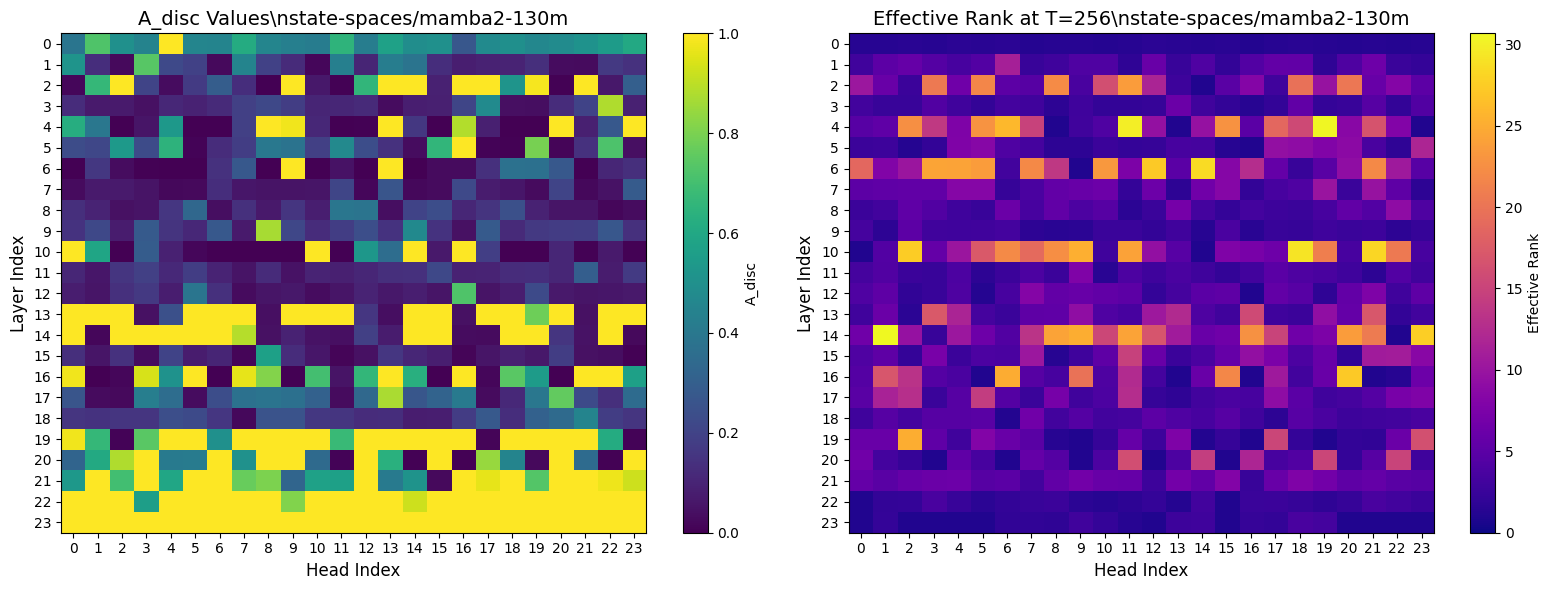

\nGenerating heatmaps for state-spaces/mamba2-370m...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_heatmap_state-spaces_mamba2-370m.png


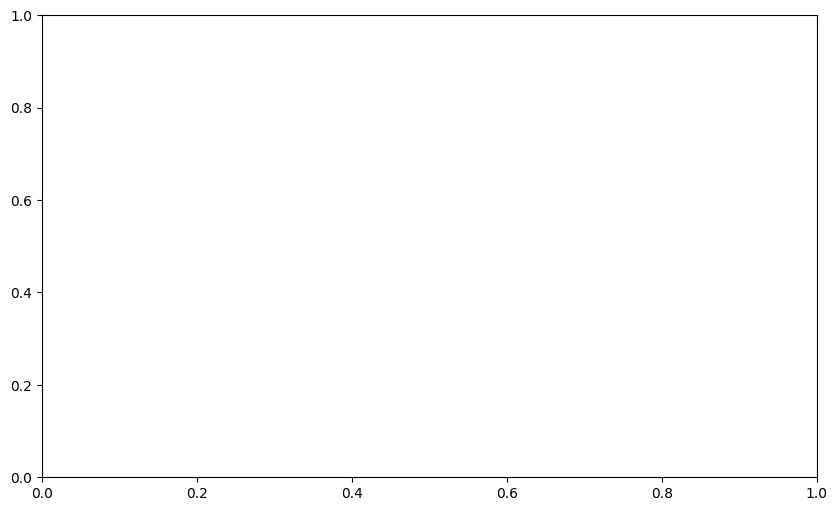

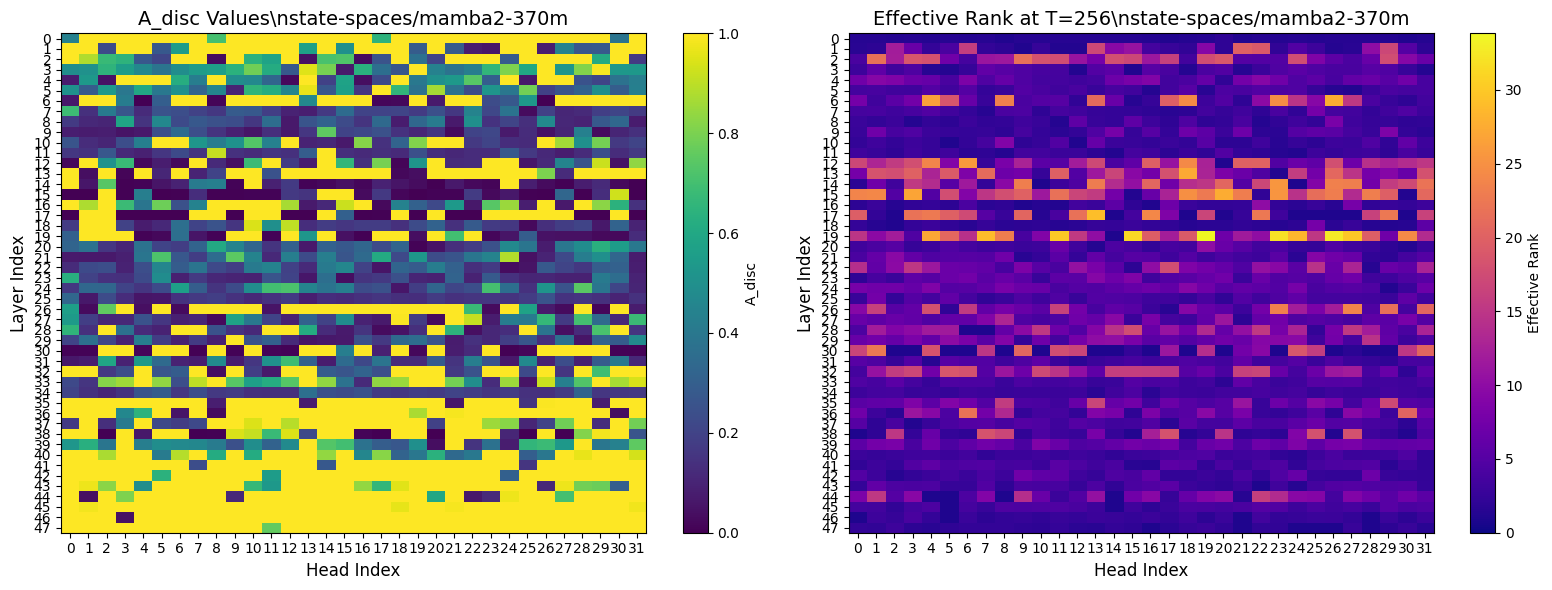

\nGenerating heatmaps for state-spaces/mamba2-780m...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_heatmap_state-spaces_mamba2-780m.png


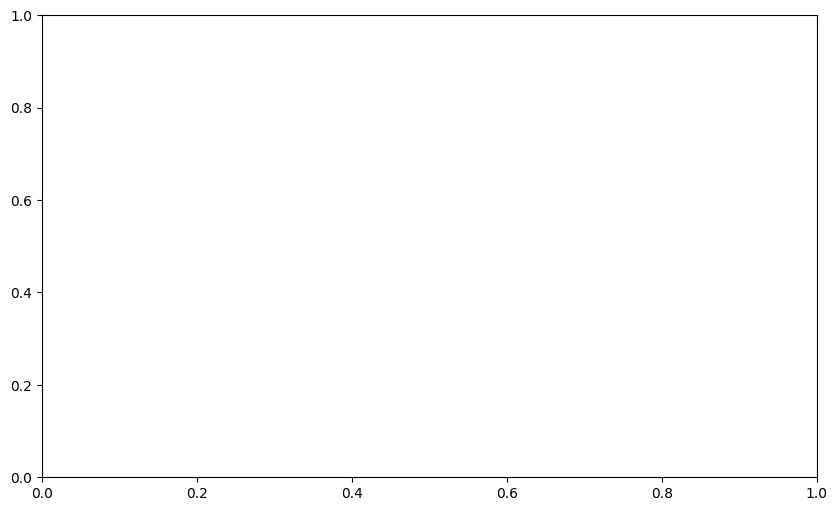

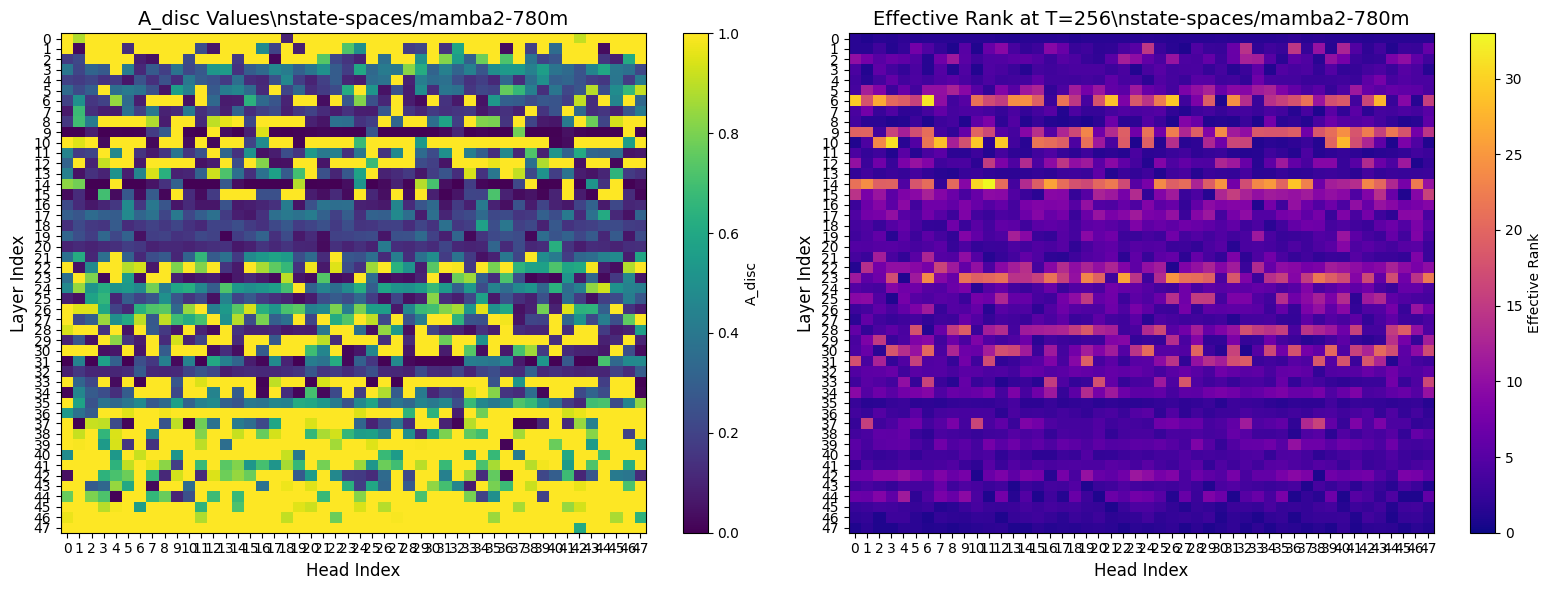

\nGenerating heatmaps for state-spaces/mamba2-1.3b...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_heatmap_state-spaces_mamba2-1.3b.png


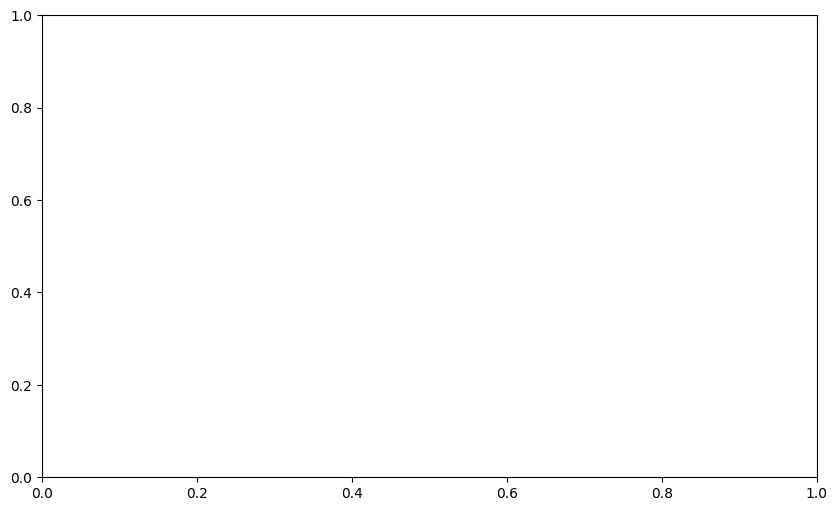

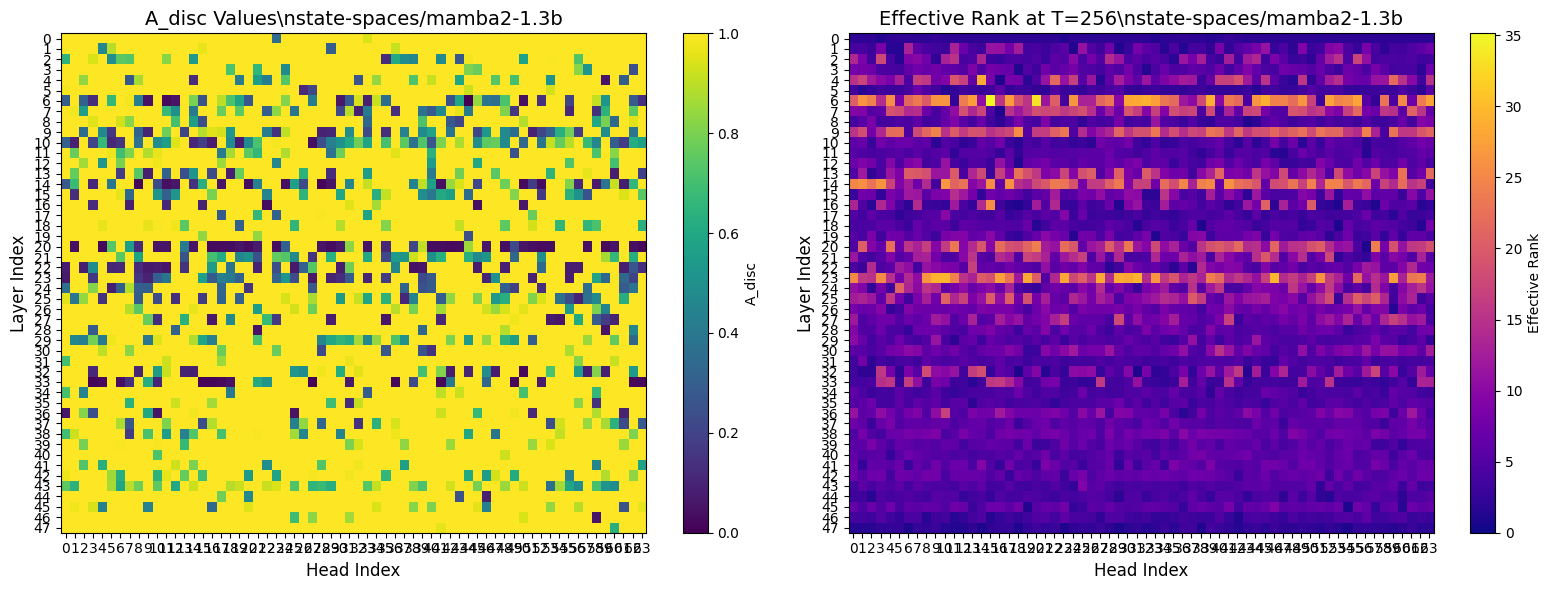

\nGenerating heatmaps for state-spaces/mamba2-2.7b...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_heatmap_state-spaces_mamba2-2.7b.png


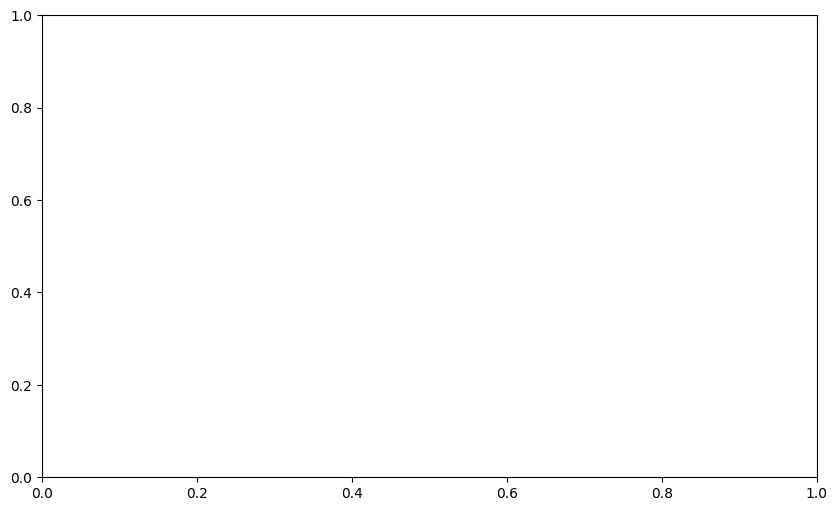

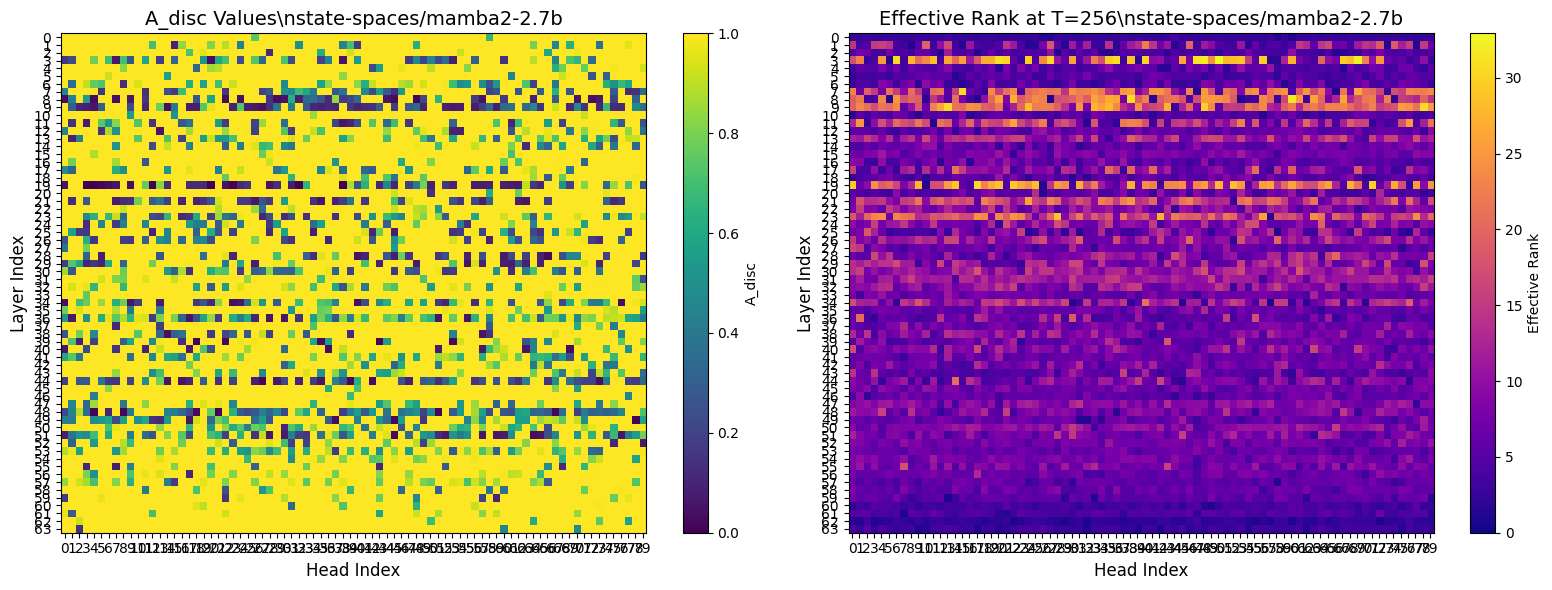

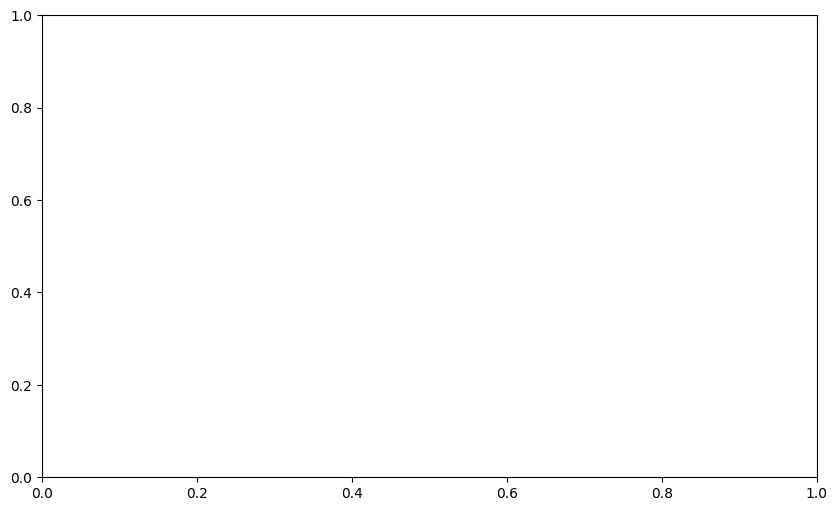

In [23]:
# Create heatmap for each model
for model_name, results in exp1_results.items():
    print(f"\\nGenerating heatmaps for {model_name}...")

    A_disc = results['A_disc']
    ranks_256 = results['ranks_256']
    head_types = results['head_types']

    n_layers, n_heads = A_disc.shape

    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Subplot 1: A_disc heatmap
    im1 = axes[0].imshow(A_disc, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    axes[0].set_xlabel('Head Index', fontsize=12)
    axes[0].set_ylabel('Layer Index', fontsize=12)
    axes[0].set_title(f'A_disc Values\\n{model_name}', fontsize=14)
    axes[0].set_xticks(range(n_heads))
    axes[0].set_yticks(range(n_layers))
    plt.colorbar(im1, ax=axes[0], label='A_disc')

    # Subplot 2: Effective rank at T=256
    im2 = axes[1].imshow(ranks_256, cmap='plasma', aspect='auto', vmin=0)
    axes[1].set_xlabel('Head Index', fontsize=12)
    axes[1].set_ylabel('Layer Index', fontsize=12)
    axes[1].set_title(f'Effective Rank at T=256\\n{model_name}', fontsize=14)
    axes[1].set_xticks(range(n_heads))
    axes[1].set_yticks(range(n_layers))
    plt.colorbar(im2, ax=axes[1], label='Effective Rank')

    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/exp1_heatmap_{model_name.replace('/', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
    plt.show()

    # Head type distribution plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Flatten head types for histogram
    # A_disc_flat = A_disc.flatten()

    # ax.hist(A_disc_flat, bins=50, alpha=0.7, edgecolor='black')
    # ax.axvline(SLOW_THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Type A threshold (≥{SLOW_THRESHOLD})')
    # ax.axvline(FAST_THRESHOLD, color='blue', linestyle='--', linewidth=2, label=f'Type C threshold (≤{FAST_THRESHOLD})')
    # ax.set_xlabel('A_disc Value', fontsize=12)
    # ax.set_ylabel('Count', fontsize=12)
    # ax.set_title(f'A_disc Distribution\\n{model_name}', fontsize=14)
    # ax.legend(fontsize=10)
    # ax.grid(alpha=0.3)

    # plt.tight_layout()
    # save_path = f"{PLOTS_DIR}/exp1_A_disc_dist_{model_name.replace('/', '_')}.png"
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    # print(f"Saved to {save_path}")
    # plt.show()

\nGenerating rank trajectory plots for state-spaces/mamba2-130m...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_layers_state-spaces_mamba2-130m.png


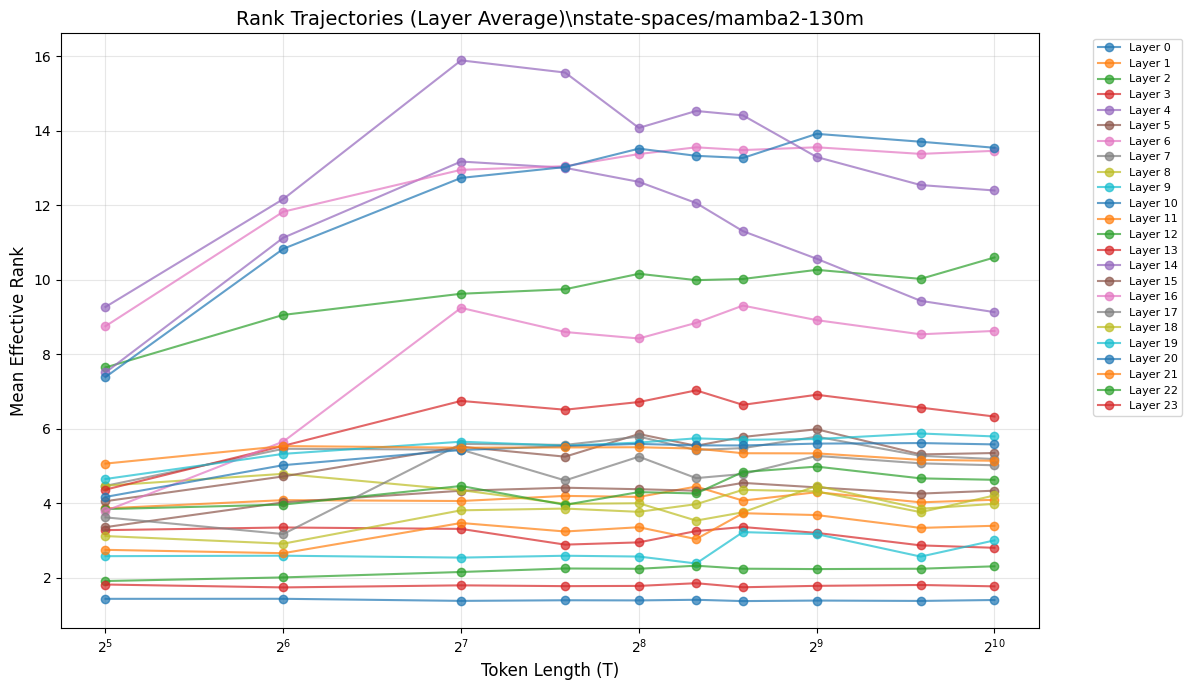

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_overall_state-spaces_mamba2-130m.png


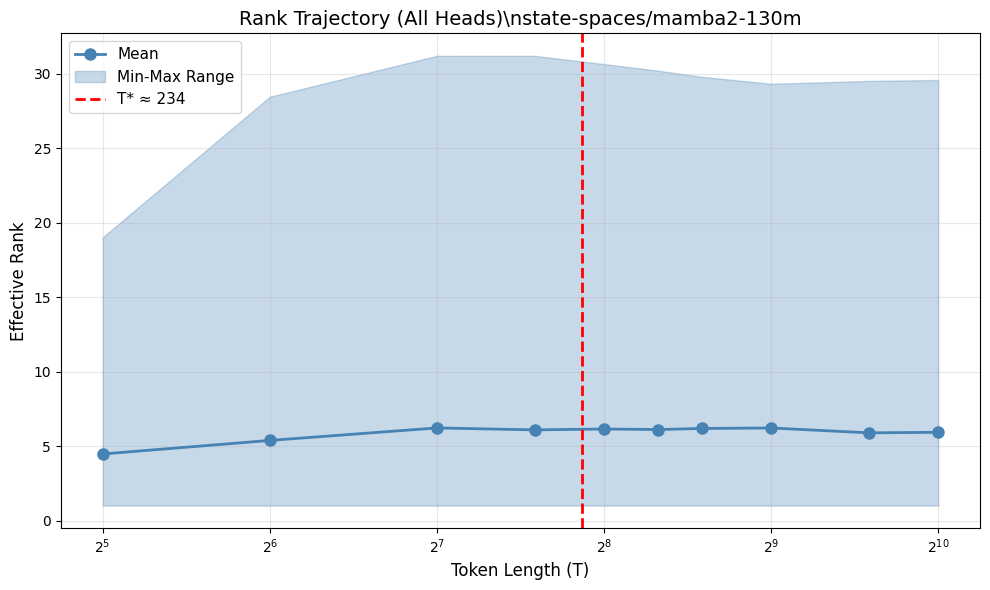

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_T_star_heatmap_state-spaces_mamba2-130m.png


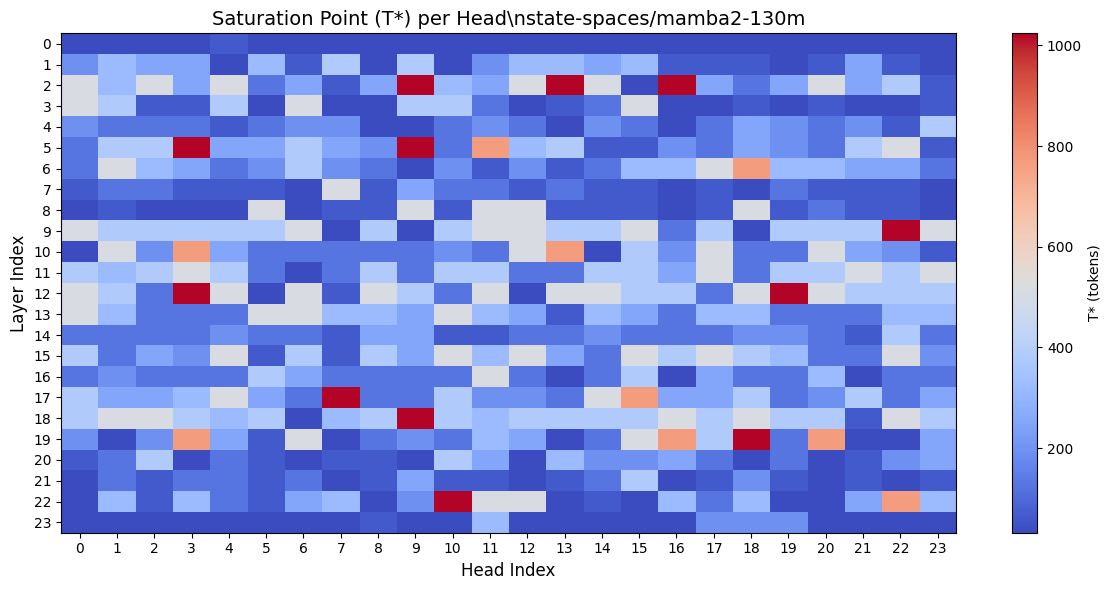

\nGenerating rank trajectory plots for state-spaces/mamba2-370m...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_layers_state-spaces_mamba2-370m.png


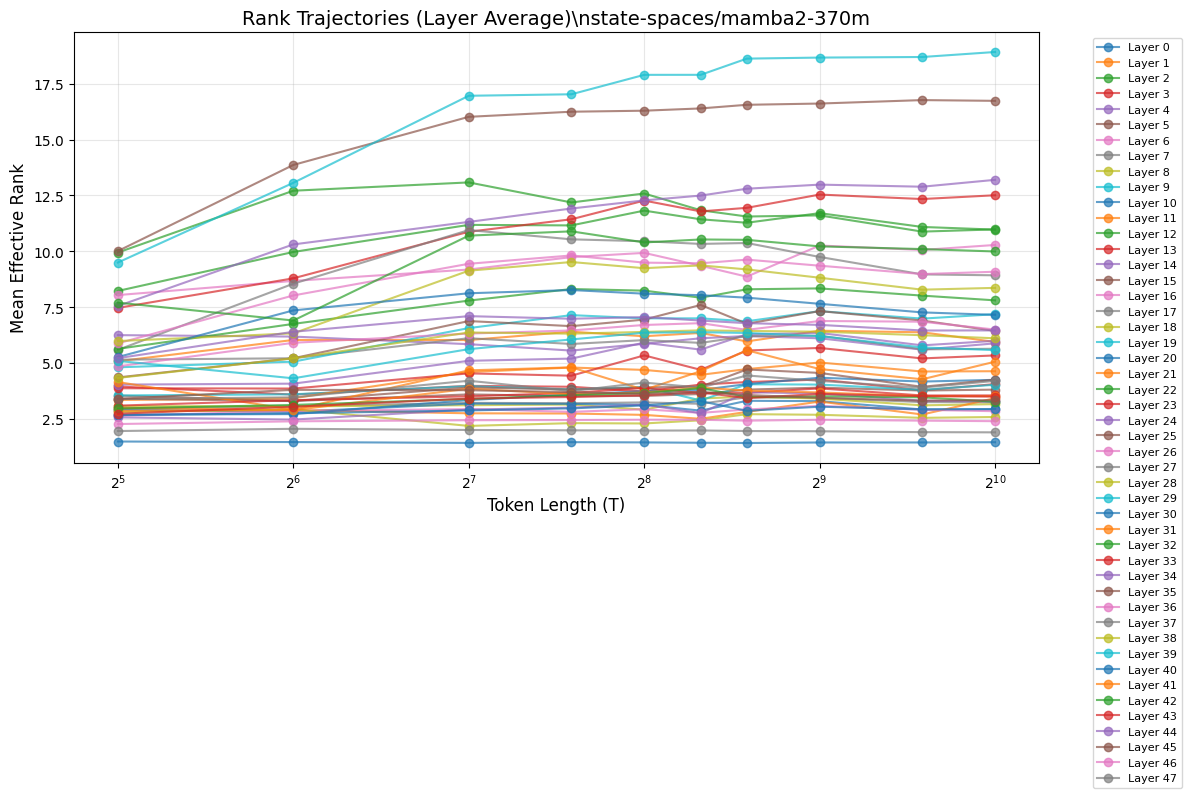

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_overall_state-spaces_mamba2-370m.png


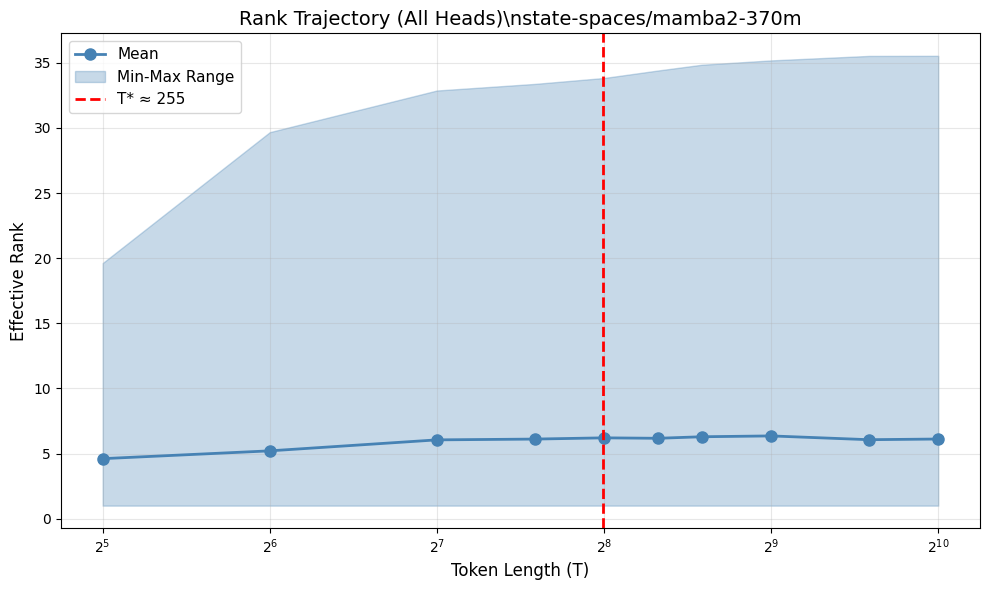

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_T_star_heatmap_state-spaces_mamba2-370m.png


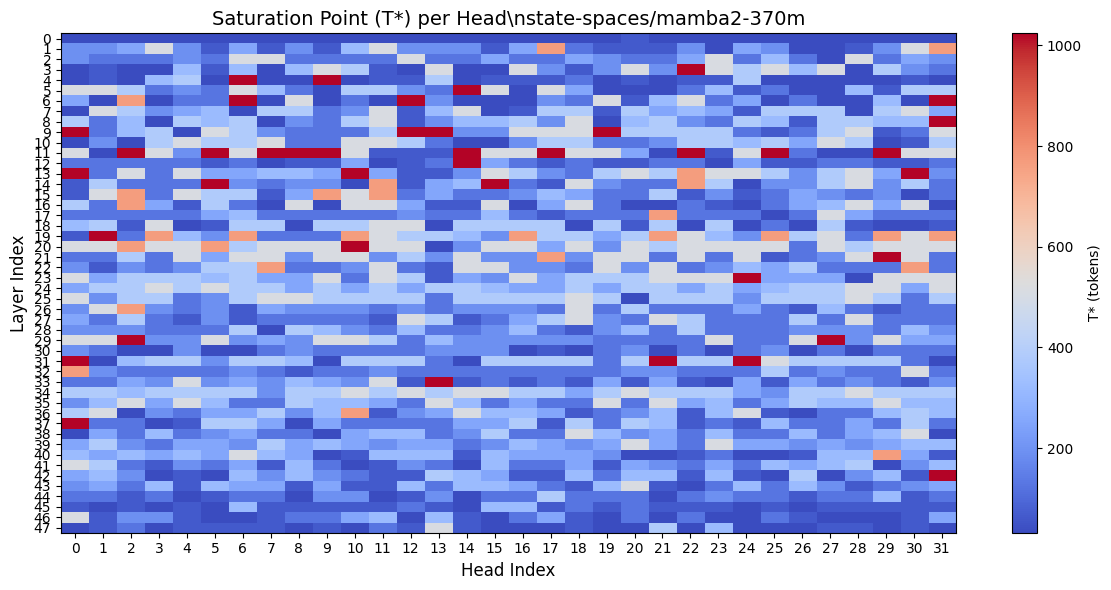

\nGenerating rank trajectory plots for state-spaces/mamba2-780m...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_layers_state-spaces_mamba2-780m.png


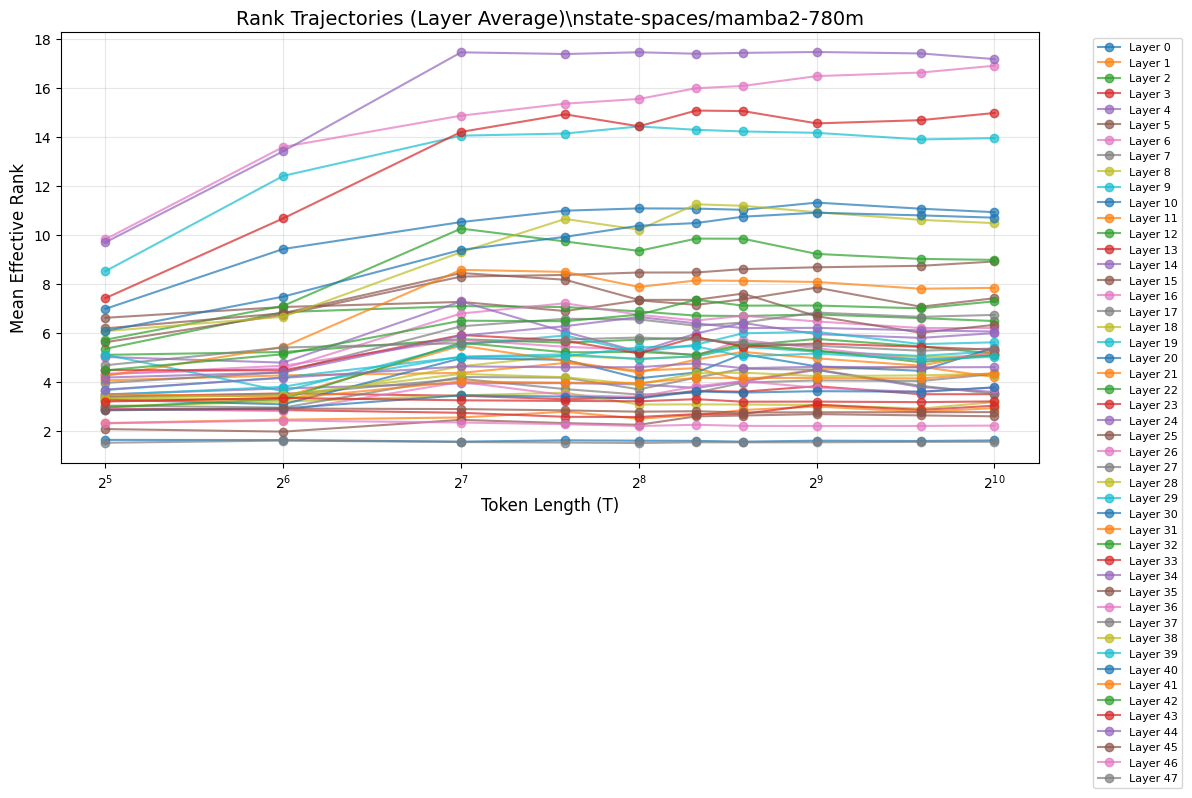

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_overall_state-spaces_mamba2-780m.png


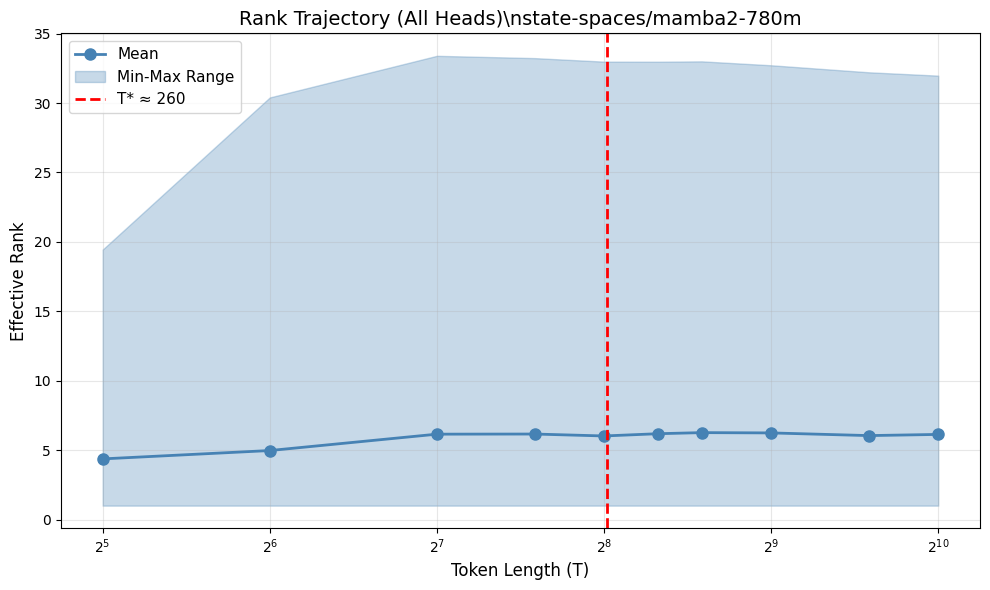

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_T_star_heatmap_state-spaces_mamba2-780m.png


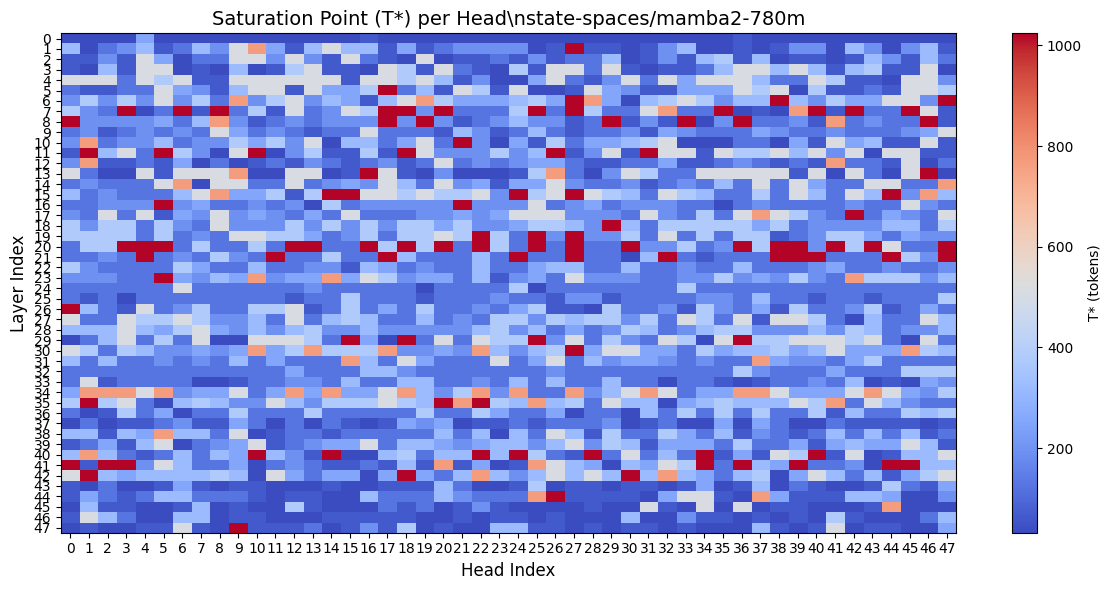

\nGenerating rank trajectory plots for state-spaces/mamba2-1.3b...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_layers_state-spaces_mamba2-1.3b.png


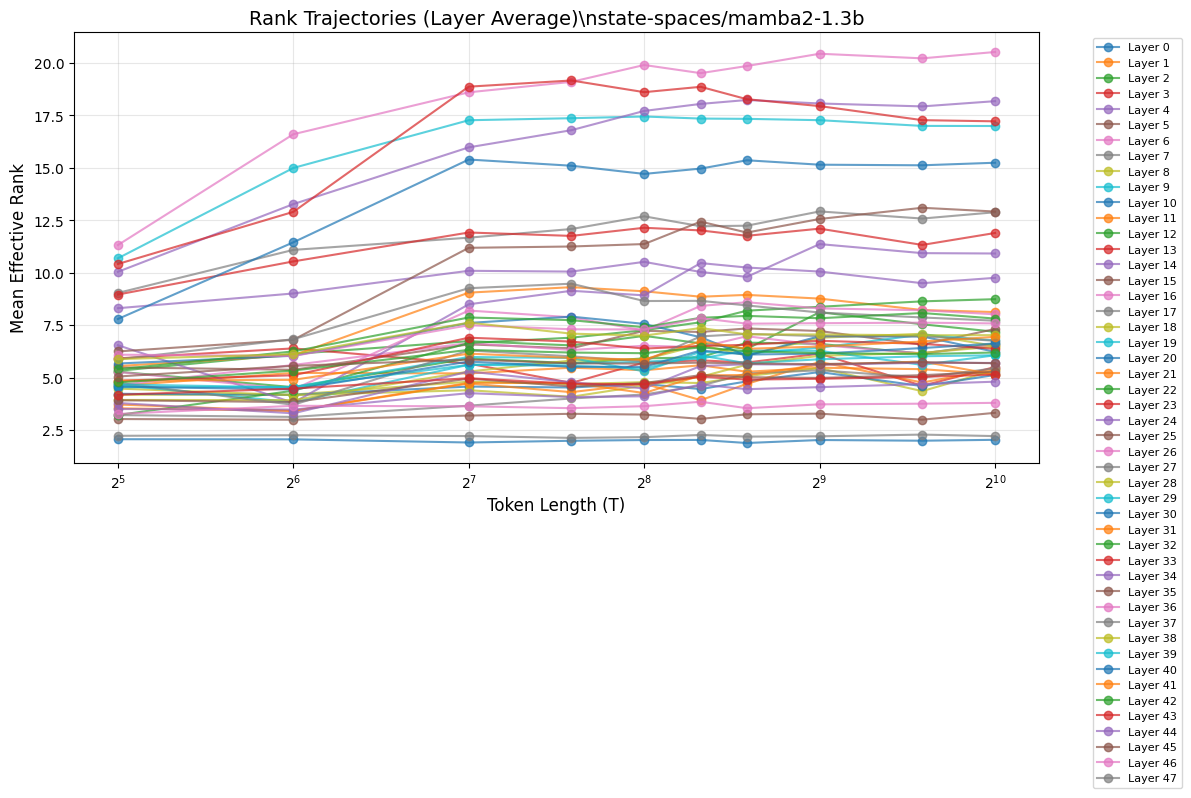

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_overall_state-spaces_mamba2-1.3b.png


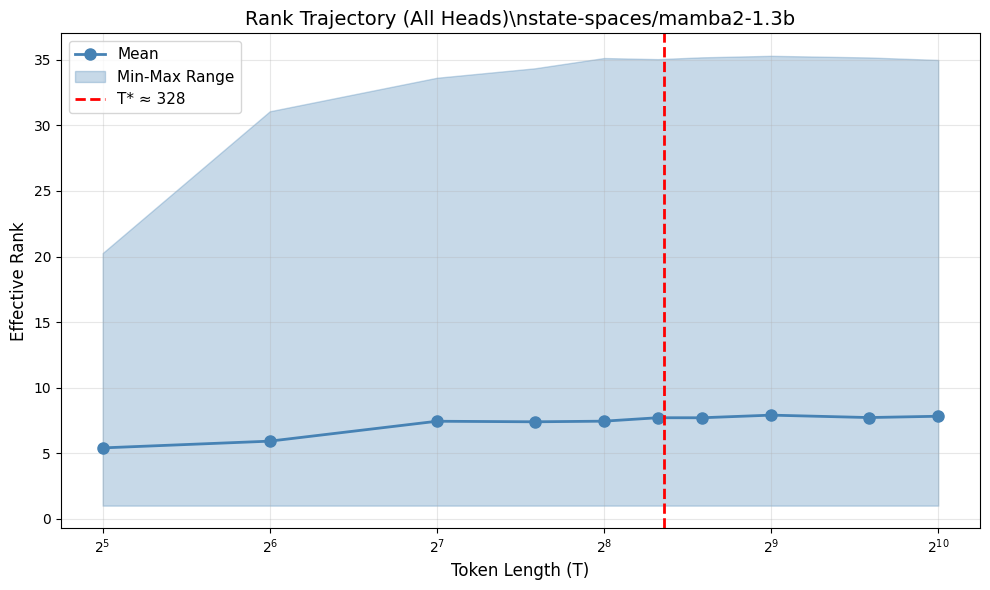

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_T_star_heatmap_state-spaces_mamba2-1.3b.png


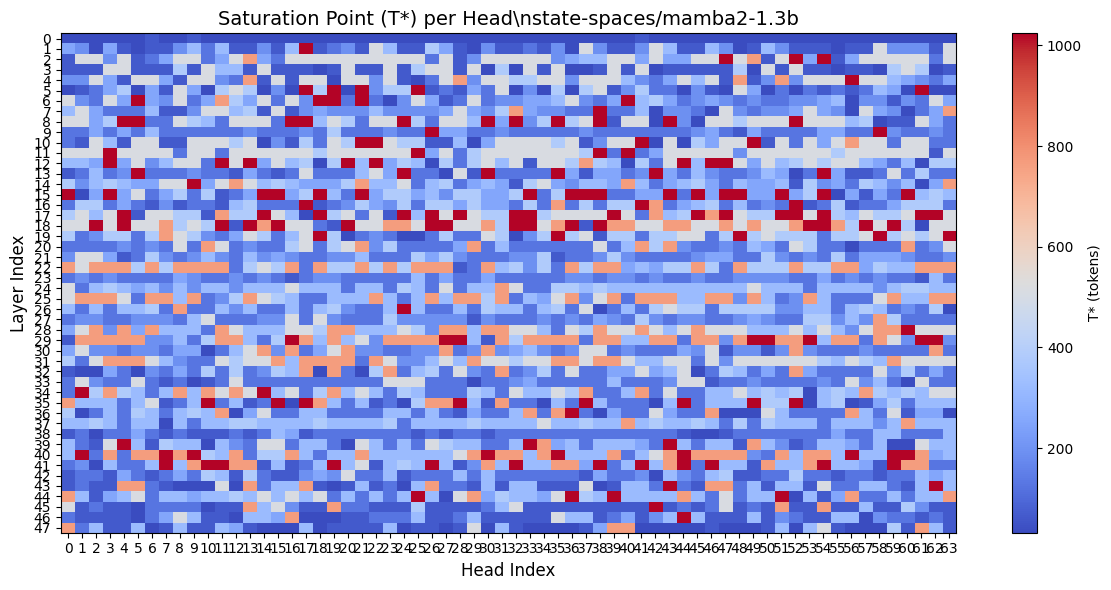

\nGenerating rank trajectory plots for state-spaces/mamba2-2.7b...
Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_layers_state-spaces_mamba2-2.7b.png


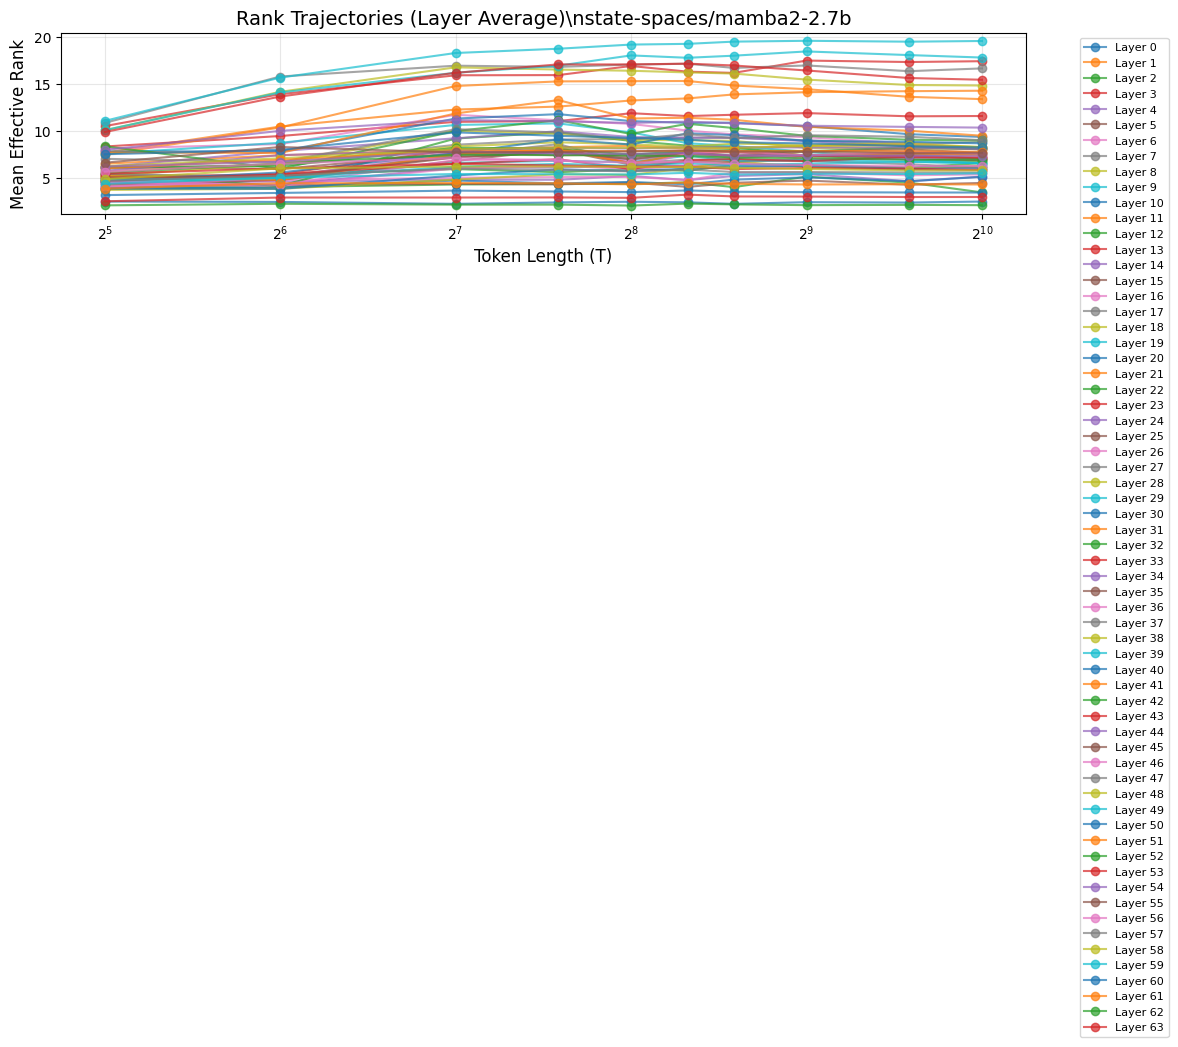

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_rank_traj_overall_state-spaces_mamba2-2.7b.png


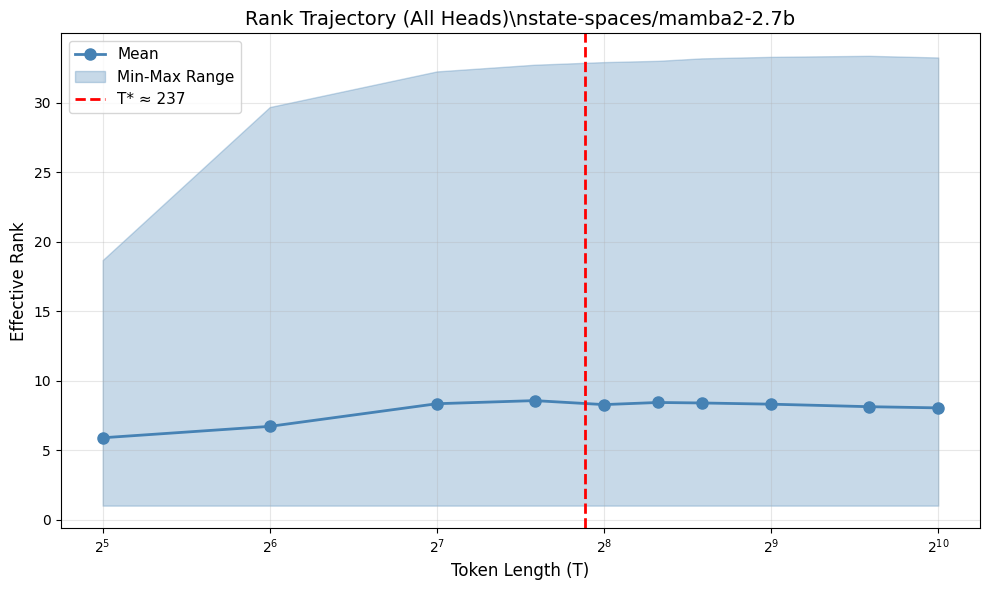

Saved to /root/smaller/mamba3_analysis/results/plots/exp1_T_star_heatmap_state-spaces_mamba2-2.7b.png


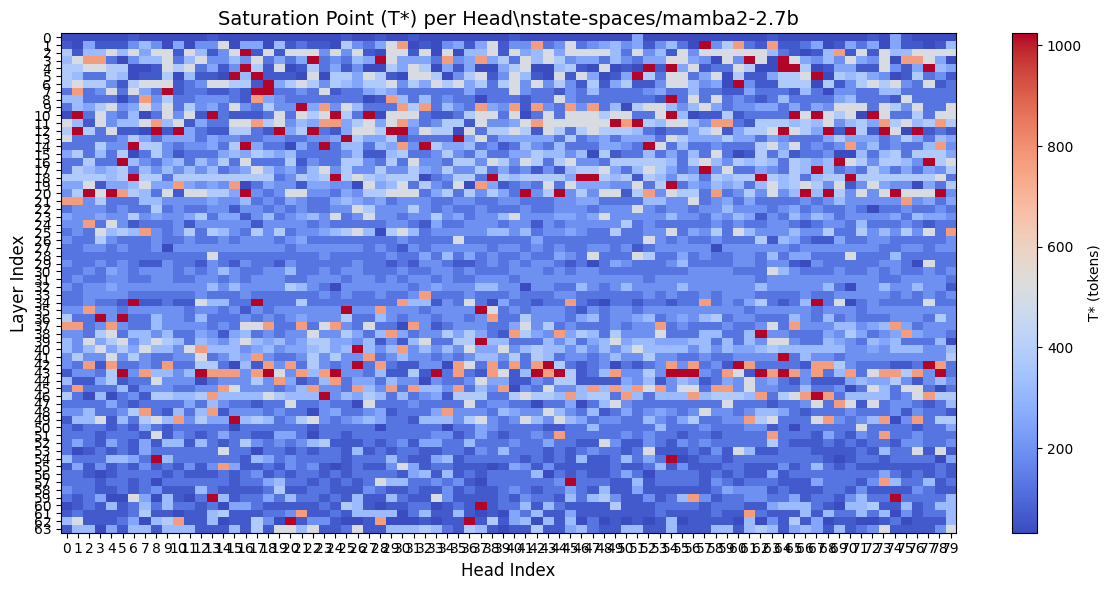

\nExperiment 1 visualizations complete!


In [24]:
for model_name, results in exp1_results.items():
    print(f"\\nGenerating rank trajectory plots for {model_name}...")

    rank_trajectories = results['rank_trajectories']  # (n_layers, n_heads, len(T_RANGE))
    T_RANGE_data = results['T_RANGE']
    n_layers, n_heads, _ = rank_trajectories.shape

    # Plot 1: Mean rank trajectory per layer
    fig, ax = plt.subplots(figsize=(12, 7))

    for layer_idx in range(n_layers):
        mean_rank = rank_trajectories[layer_idx].mean(axis=0)  # Average over heads
        ax.plot(T_RANGE_data, mean_rank, marker='o', label=f'Layer {layer_idx}', alpha=0.7)

    ax.set_xlabel('Token Length (T)', fontsize=12)
    ax.set_ylabel('Mean Effective Rank', fontsize=12)
    ax.set_title(f'Rank Trajectories (Layer Average)\\n{model_name}', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xscale('log', base=2)

    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/exp1_rank_traj_layers_{model_name.replace('/', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
    plt.show()

    # Plot 2: Min/Mean/Max across all heads and layers
    fig, ax = plt.subplots(figsize=(10, 6))

    all_heads_min = rank_trajectories.min(axis=(0, 1))
    all_heads_mean = rank_trajectories.mean(axis=(0, 1))
    all_heads_max = rank_trajectories.max(axis=(0, 1))

    ax.plot(T_RANGE_data, all_heads_mean, 'o-', linewidth=2, markersize=8, label='Mean', color='steelblue')
    ax.fill_between(T_RANGE_data, all_heads_min, all_heads_max, alpha=0.3, color='steelblue', label='Min-Max Range')

    # Mark saturation point
    T_star = results['T_star_measured']
    ax.axvline(T_star, color='red', linestyle='--', linewidth=2, label=f'T* ≈ {T_star:.0f}')

    ax.set_xlabel('Token Length (T)', fontsize=12)
    ax.set_ylabel('Effective Rank', fontsize=12)
    ax.set_title(f'Rank Trajectory (All Heads)\\n{model_name}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    ax.set_xscale('log', base=2)

    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/exp1_rank_traj_overall_{model_name.replace('/', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
    plt.show()

    # Plot 3: T* distribution heatmap
    fig, ax = plt.subplots(figsize=(12, 6))

    T_star_per_head = results['T_star_per_head']
    im = ax.imshow(T_star_per_head, cmap='coolwarm', aspect='auto')
    ax.set_xlabel('Head Index', fontsize=12)
    ax.set_ylabel('Layer Index', fontsize=12)
    ax.set_title(f'Saturation Point (T*) per Head\\n{model_name}', fontsize=14)
    ax.set_xticks(range(n_heads))
    ax.set_yticks(range(n_layers))
    plt.colorbar(im, ax=ax, label='T* (tokens)')

    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/exp1_T_star_heatmap_{model_name.replace('/', '_')}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
    plt.show()

print("\\nExperiment 1 visualizations complete!")

## 5. Experiment 2: State Similarity (Semantic Separability)

This experiment tests whether SSM states can distinguish between topics:
1. Extract states (Type A, Type C, All heads, Hidden state) for documents
2. Compute intra-topic vs inter-topic cosine similarity
3. Statistical significance testing
4. Visualization (heatmaps, t-SNE, gap analysis)

In [31]:
print("="*60)
print("Experiment 2: State Similarity Analysis")
print("="*60)

# Use primary model
model_name = MODEL_LIST[4]
print(f"\\nLoading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
tokenizer.pad_token = tokenizer.eos_token

# Load model
model = MambaLMHeadModel.from_pretrained(model_name, device=device, dtype=torch.float32)
model.eval()

# Get architecture info
n_layers = len(model.backbone.layers)
n_heads = model.backbone.layers[0].mixer.A_log.shape[0]

# Get head types (reuse from Exp1 if available)
if model_name in exp1_results:
    print("Reusing head types from Experiment 1")
    head_types = exp1_results[model_name]['head_types']
else:
    print("Computing head types...")
    A_disc = get_A_disc(model)
    head_types = classify_heads(A_disc, SLOW_THRESHOLD, FAST_THRESHOLD)

print(f"Architecture: {n_layers} layers, {n_heads} heads")

Experiment 2: State Similarity Analysis
\nLoading model: state-spaces/mamba2-2.7b
Reusing head types from Experiment 1
Architecture: 64 layers, 80 heads


In [32]:
# Prepare all documents
all_docs = []
doc_labels = []

for topic, docs in TOPIC_DOCS.items():
    for doc in docs:
        all_docs.append(doc)
        doc_labels.append(topic)

n_docs = len(all_docs)
print(f"\\nTotal documents: {n_docs} ({N_TOPICS} topics × {N_DOCS_PER_TOPIC} docs)")

# Storage for different state types
# Each will be (n_docs, feature_dim) after flattening
state_vectors = {
    'type_A': [],
    'type_C': [],
    'all_heads': [],
    'hidden': [],
}

print("\nExtracting states for all documents...")

for doc_idx, doc in enumerate(tqdm(all_docs, desc="Documents")):
  # Tokenize
  input_ids = tokenizer(doc, return_tensors='pt', truncation=True,
max_length=DOC_LEN)['input_ids'].to(device)

  # Get SSM states
  states = get_ssm_states(model, input_ids)

  # Get hidden states (수정됨!)
  with torch.no_grad():
      hidden_state = model.backbone(input_ids)  # (batch, seq_len,hidden_dim)
      hidden_state = hidden_state.mean(dim=1)   # (batch, hidden_dim) -sequence 평균

  # Extract Type A heads
  type_A_states = []
  for layer_idx in range(n_layers):
      if layer_idx in states:
          state = states[layer_idx]  # (n_heads, headdim, d_state)
          for head_idx in range(n_heads):
              if head_types['A'][layer_idx, head_idx]:
                  type_A_states.append(state[head_idx].flatten())

  if type_A_states:
      type_A_vec = torch.cat(type_A_states).cpu().numpy()
      state_vectors['type_A'].append(type_A_vec)
  else:
      # Fallback if no Type A heads
      state_vectors['type_A'].append(np.zeros(1))

  # Extract Type C heads
  type_C_states = []
  for layer_idx in range(n_layers):
      if layer_idx in states:
          state = states[layer_idx]
          for head_idx in range(n_heads):
              if head_types['C'][layer_idx, head_idx]:
                  type_C_states.append(state[head_idx].flatten())

  if type_C_states:
      type_C_vec = torch.cat(type_C_states).cpu().numpy()
      state_vectors['type_C'].append(type_C_vec)
  else:
      state_vectors['type_C'].append(np.zeros(1))

  # All heads
  all_states = []
  for layer_idx in range(n_layers):
      if layer_idx in states:
          state = states[layer_idx]
          all_states.append(state.flatten())

  all_vec = torch.cat(all_states).cpu().numpy()
  state_vectors['all_heads'].append(all_vec)

  # Hidden state
  hidden_vec = hidden_state.cpu().numpy().flatten()
  state_vectors['hidden'].append(hidden_vec)

# Convert to arrays
for key in state_vectors:
  state_vectors[key] = np.array(state_vectors[key])
  print(f"{key}: shape {state_vectors[key].shape}")

print("\nState extraction complete!")

\nTotal documents: 36 (5 topics × 6 docs)

Extracting states for all documents...


Documents: 100%|██████████| 36/36 [00:14<00:00,  2.48it/s]


type_A: shape (36, 29556736)
type_C: shape (36, 6242304)
all_heads: shape (36, 41943040)
hidden: shape (36, 2560)

State extraction complete!


In [33]:
print("\\nComputing similarity matrices...")

similarity_matrices = {}
separability_results = {}

for state_type, vectors in state_vectors.items():
    print(f"\\n--- {state_type.upper()} ---")

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(vectors)  # (n_docs, n_docs)
    similarity_matrices[state_type] = sim_matrix

    # Create topic label array
    topic_list = list(TOPIC_DOCS.keys())
    topic_to_idx = {topic: idx for idx, topic in enumerate(topic_list)}
    doc_topic_indices = [topic_to_idx[label] for label in doc_labels]

    # Compute intra-topic and inter-topic similarities
    intra_sims = []
    inter_sims = []

    for i in range(n_docs):
        for j in range(i + 1, n_docs):  # Upper triangle only
            if doc_topic_indices[i] == doc_topic_indices[j]:
                intra_sims.append(sim_matrix[i, j])
            else:
                inter_sims.append(sim_matrix[i, j])

    intra_mean = np.mean(intra_sims)
    intra_std = np.std(intra_sims)
    inter_mean = np.mean(inter_sims)
    inter_std = np.std(inter_sims)
    gap = intra_mean - inter_mean

    print(f"Intra-topic similarity: {intra_mean:.4f} ± {intra_std:.4f}")
    print(f"Inter-topic similarity: {inter_mean:.4f} ± {inter_std:.4f}")
    print(f"Separability gap: {gap:.4f}")

    # Statistical test
    t_stat, p_value = ttest_ind(intra_sims, inter_sims)
    print(f"t-test: t={t_stat:.3f}, p={p_value:.2e}")

    separability_results[state_type] = {
        'intra_mean': intra_mean,
        'intra_std': intra_std,
        'inter_mean': inter_mean,
        'inter_std': inter_std,
        'gap': gap,
        't_stat': t_stat,
        'p_value': p_value,
    }

# Save results
exp2_results = {
    'state_vectors': state_vectors,
    'similarity_matrices': similarity_matrices,
    'separability_results': separability_results,
    'doc_labels': doc_labels,
    'topic_list': topic_list,
}

save_path = f"{RESULTS_DIR}/exp2_results.npz"
np.savez(
    save_path,
    **{f'{k}_sim': v for k, v in similarity_matrices.items()},
    doc_labels=doc_labels,
    topic_list=topic_list
)

with open(f"{RESULTS_DIR}/exp2_separability.json", 'w') as f:
    # Convert numpy types to native Python for JSON
    json_results = {}
    for k, v in separability_results.items():
        json_results[k] = {key: float(val) for key, val in v.items()}
    json.dump(json_results, f, indent=2)

print(f"\\nResults saved to {RESULTS_DIR}")

\nComputing similarity matrices...
\n--- TYPE_A ---
Intra-topic similarity: 0.6357 ± 0.0493
Inter-topic similarity: 0.5310 ± 0.0475
Separability gap: 0.1047
t-test: t=19.214, p=4.58e-65
\n--- TYPE_C ---
Intra-topic similarity: 0.9741 ± 0.0059
Inter-topic similarity: 0.9643 ± 0.0086
Separability gap: 0.0099
t-test: t=10.479, p=8.64e-24
\n--- ALL_HEADS ---
Intra-topic similarity: 0.9731 ± 0.0062
Inter-topic similarity: 0.9619 ± 0.0090
Separability gap: 0.0112
t-test: t=11.314, p=3.88e-27
\n--- HIDDEN ---
Intra-topic similarity: 0.8534 ± 0.0779
Inter-topic similarity: 0.7096 ± 0.1197
Separability gap: 0.1439
t-test: t=10.998, p=7.52e-26
\nResults saved to /root/smaller/mamba3_analysis/results


\nGenerating similarity heatmaps...
Saved to /root/smaller/mamba3_analysis/results/plots/exp2_similarity_type_A.png


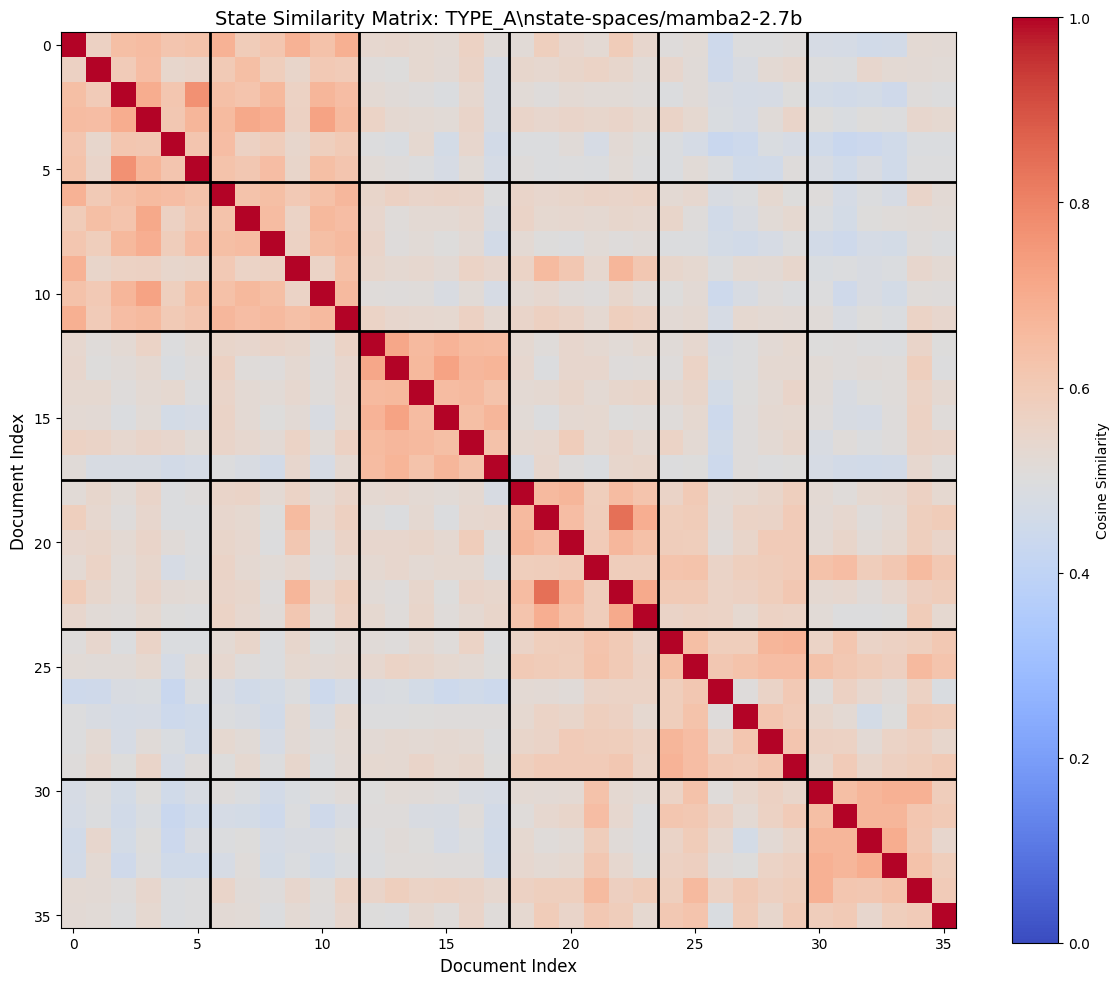

Saved to /root/smaller/mamba3_analysis/results/plots/exp2_similarity_type_C.png


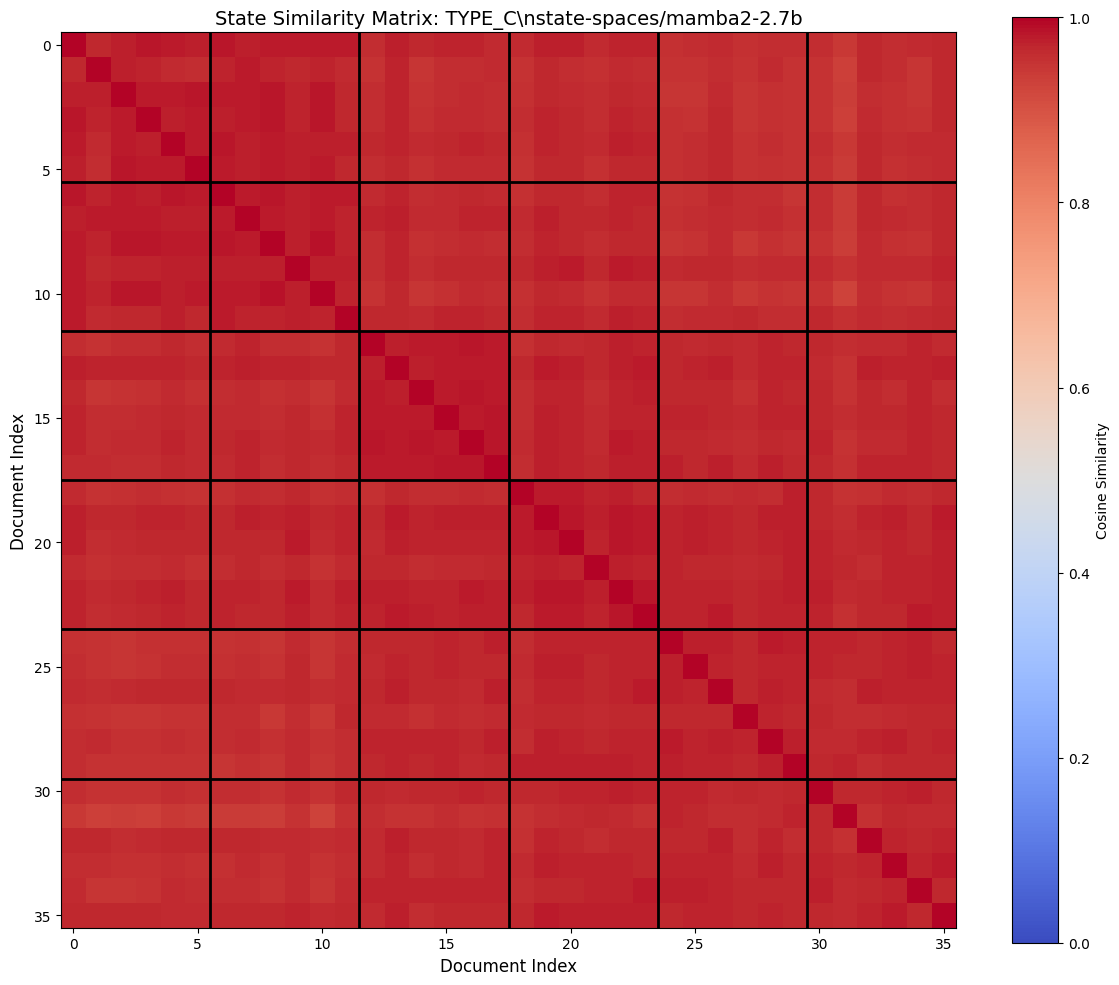

Saved to /root/smaller/mamba3_analysis/results/plots/exp2_similarity_all_heads.png


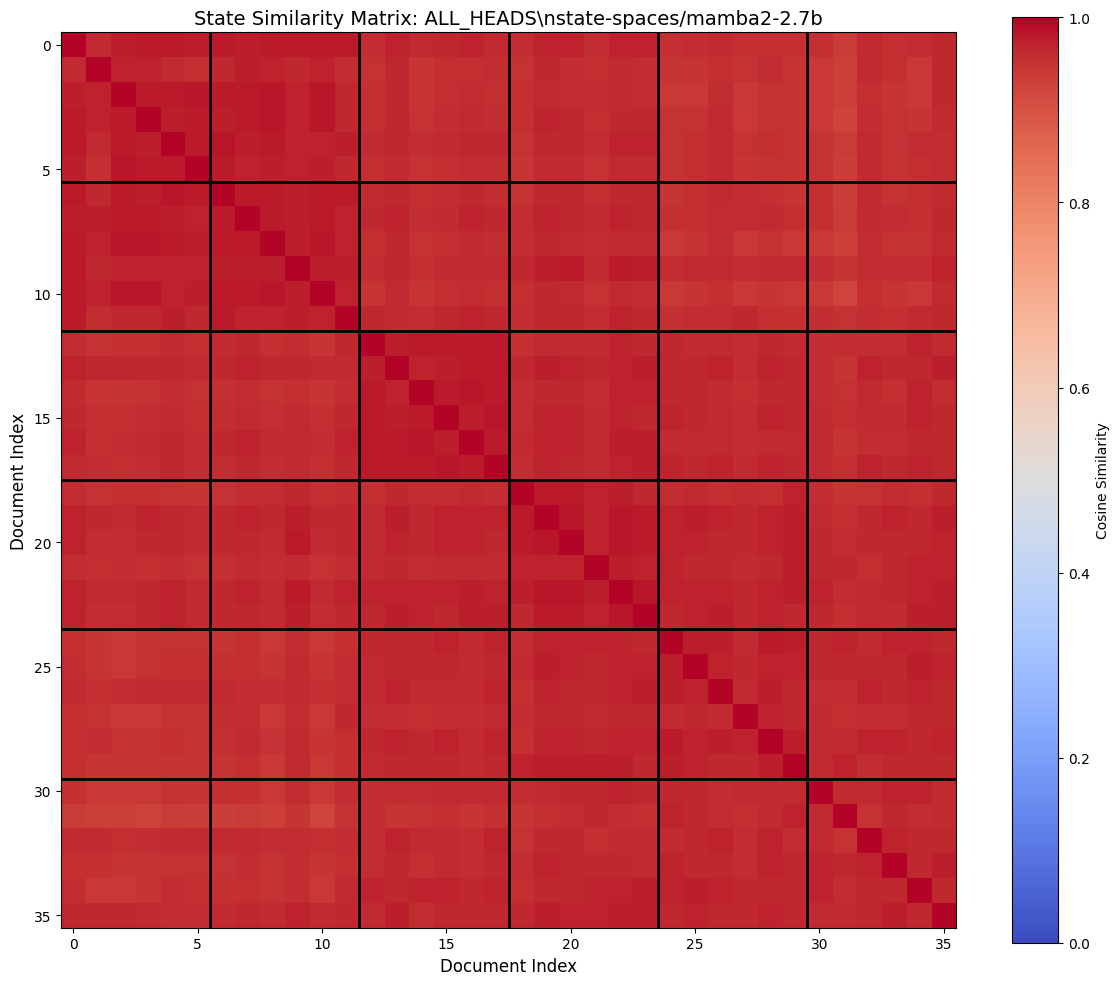

Saved to /root/smaller/mamba3_analysis/results/plots/exp2_similarity_hidden.png


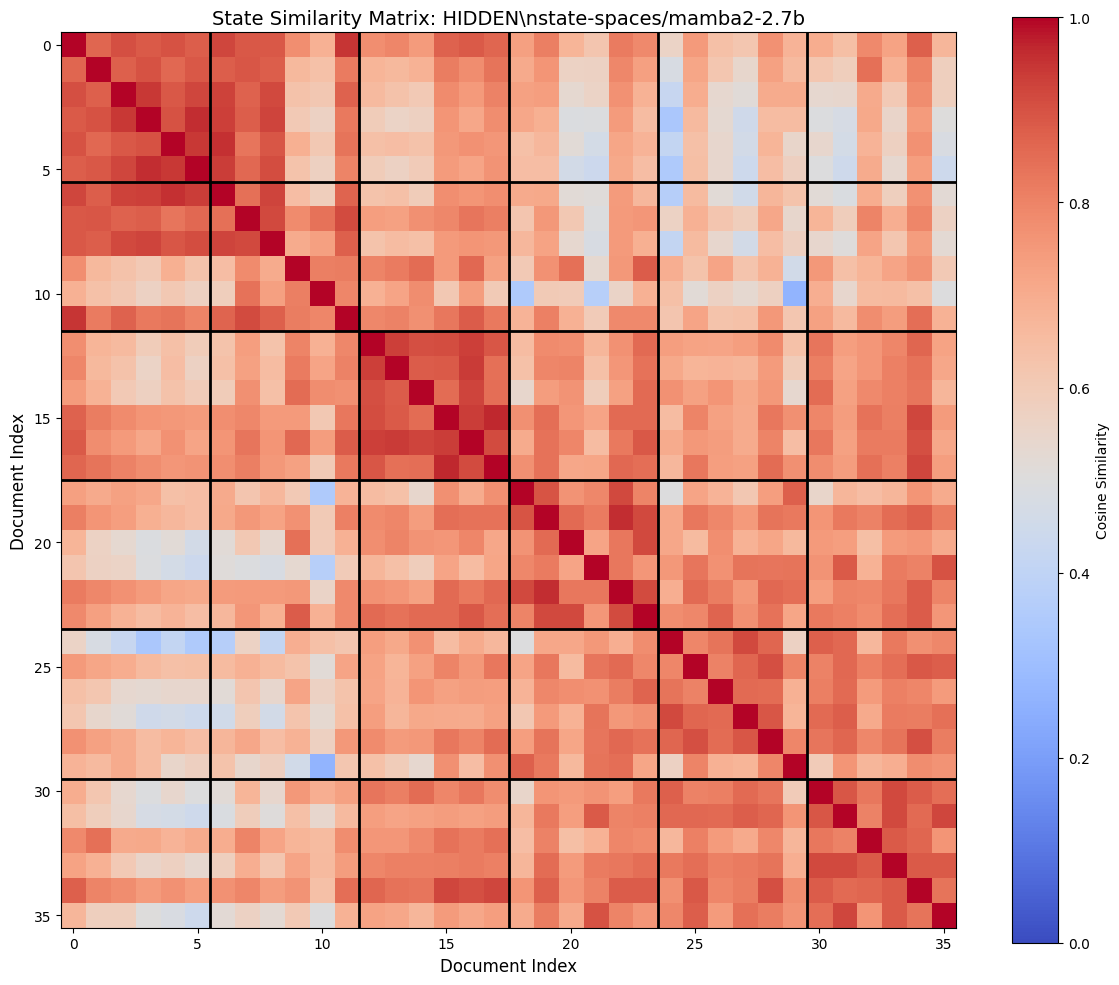

In [34]:
print("\\nGenerating similarity heatmaps...")

# Create heatmap for each state type
for state_type, sim_matrix in similarity_matrices.items():
    fig, ax = plt.subplots(figsize=(12, 10))

    # Sort by topic for better visualization
    sort_indices = np.argsort(doc_labels)
    sim_matrix_sorted = sim_matrix[sort_indices][:, sort_indices]
    labels_sorted = [doc_labels[i] for i in sort_indices]

    im = ax.imshow(sim_matrix_sorted, cmap='coolwarm', vmin=0, vmax=1)

    # Add topic boundaries
    topic_boundaries = []
    current_topic = labels_sorted[0]
    for i, topic in enumerate(labels_sorted):
        if topic != current_topic:
            topic_boundaries.append(i - 0.5)
            current_topic = topic

    for boundary in topic_boundaries:
        ax.axhline(boundary, color='black', linewidth=2)
        ax.axvline(boundary, color='black', linewidth=2)

    # Labels
    ax.set_title(f'State Similarity Matrix: {state_type.upper()}\\n{model_name}', fontsize=14)
    ax.set_xlabel('Document Index', fontsize=12)
    ax.set_ylabel('Document Index', fontsize=12)
    plt.colorbar(im, ax=ax, label='Cosine Similarity')

    plt.tight_layout()
    save_path = f"{PLOTS_DIR}/exp2_similarity_{state_type}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
    plt.show()

\nGenerating separability gap chart...
Saved to /root/smaller/mamba3_analysis/results/plots/exp2_separability_gap.png


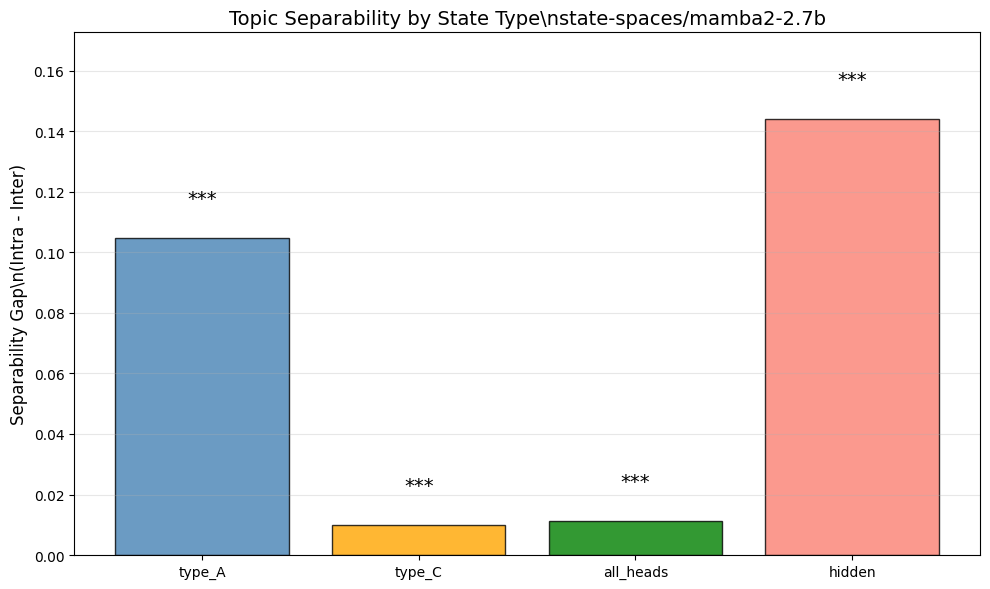

In [36]:
print("\\nGenerating separability gap chart...")

fig, ax = plt.subplots(figsize=(10, 6))

state_types = list(separability_results.keys())
gaps = [separability_results[st]['gap'] for st in state_types]
p_values = [separability_results[st]['p_value'] for st in state_types]

bars = ax.bar(state_types, gaps, color=['steelblue', 'orange', 'green', 'salmon'], alpha=0.8, edgecolor='black')

# Add significance stars
for i, (bar, p_val) in enumerate(zip(bars, p_values)):
    height = bar.get_height()
    if p_val < 0.001:
        stars = '***'
    elif p_val < 0.01:
        stars = '**'
    elif p_val < 0.05:
        stars = '*'
    else:
        stars = 'ns'
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, stars, ha='center', va='bottom', fontsize=14)

ax.set_ylabel('Separability Gap\\n(Intra - Inter)', fontsize=12)
ax.set_title(f'Topic Separability by State Type\\n{model_name}', fontsize=14)
ax.set_ylim(0, max(gaps) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = f"{PLOTS_DIR}/exp2_separability_gap.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

## 6. Experiment 3: State Injection Validation (3-tier QA)

**Conditions**
- A (Oracle)  : `[doc + query]` → full forward → generate
- B (Inject)  : doc → state extracted → inject + query → generate
- C (No ctx)  : query only → generate
- D (Wrong)   : wrong doc state + query → generate

**Metric** : keyword hit-rate per tier + Oracle-Inject MSE per layer

**Tier breakdown**
- `synthetic`     → model has zero prior knowledge; hit = injection worked
- `obscure_trivia` → exact numbers model likely doesn't know
- `multi_hop`     → state must hold two linked facts simultaneously


In [8]:
print("="*60)
print("Experiment 3: State Injection Validation")
print("="*60)

EXP3_MODEL = MODEL_LIST[4]
print(f"Loading {EXP3_MODEL}...")

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neox-20b")
tokenizer.pad_token = tokenizer.eos_token
model = MambaLMHeadModel.from_pretrained(EXP3_MODEL, device=device, dtype=torch.float32)
model.eval()
print("Model ready.")

Experiment 3: State Injection Validation
Loading state-spaces/mamba2-2.7b...
Model ready.


In [9]:
exp3_results = {k: [] for k in ['A_oracle','B_inject','C_no_ctx','D_wrong']}
exp3_mse     = []

for qa_idx, qa in enumerate(tqdm(QA_PAIRS, desc="QA pairs")):
    doc = qa['document']
    q   = qa['question']
    kws = qa['keywords']

    # ── A: Oracle ─────────────────────────────────────────────────────
    oracle_input = doc + " " + q
    oracle_ids   = tokenizer(oracle_input, return_tensors='pt')['input_ids'].to(device)
    with torch.no_grad():
        oracle_out = model.generate(oracle_ids,
                                    max_length=oracle_ids.shape[1]+80,
                                    eos_token_id=tokenizer.eos_token_id)
    oracle_ans   = tokenizer.decode(oracle_out[0, oracle_ids.shape[1]:],
                                    skip_special_tokens=True).strip()
    oracle_state = extract_state(model, tokenizer, oracle_input, device)

    # ── B: Inject ─────────────────────────────────────────────────────
    doc_state  = extract_state(model, tokenizer, doc, device)
    inject_ans, inject_final_state = inject_state_and_generate(
        model, tokenizer, q, doc_state,
        max_new_tokens=200, device=device)

    mse_per_layer, mean_mse = compute_state_mse(oracle_state, inject_final_state)

    # ── C: No context ─────────────────────────────────────────────────
    no_ctx_ids = tokenizer(q, return_tensors='pt')['input_ids'].to(device)
    with torch.no_grad():
        no_ctx_out = model.generate(no_ctx_ids,
                                    max_length=no_ctx_ids.shape[1]+80,
                                    eos_token_id=tokenizer.eos_token_id)
    no_ctx_ans = tokenizer.decode(no_ctx_out[0, no_ctx_ids.shape[1]:],
                                  skip_special_tokens=True).strip()

    # ── D: Wrong context ──────────────────────────────────────────────
    wrong_doc   = QA_PAIRS[(qa_idx + 1) % len(QA_PAIRS)]['document']
    wrong_state = extract_state(model, tokenizer, wrong_doc, device)
    wrong_ans, inject_wrong_state   = inject_state_and_generate(
        model, tokenizer, q, wrong_state,
        max_new_tokens=200, device=device)

    # ── Store ──────────────────────────────────────────────────────────
    for cond, ans in [('A_oracle', oracle_ans), ('B_inject', inject_ans),
                      ('C_no_ctx', no_ctx_ans), ('D_wrong',  wrong_ans)]:
        exp3_results[cond].append({
            'qa_idx': qa_idx, 'tier': qa['tier'],
            'question': q, 'keywords': kws,
            'answer': ans, 'hit': check_keywords(ans, kws),
        })

    exp3_mse.append({'qa_idx': qa_idx, 'tier': qa['tier'],
                     'mse_per_layer': mse_per_layer, 'mean_mse': mean_mse})

    print(f"[{qa_idx}] {qa['tier']:14s} | "
          f"A={'✓' if exp3_results['A_oracle'][-1]['hit'] else '✗'}  "
          f"B={'✓' if exp3_results['B_inject'][-1]['hit'] else '✗'}  "
          f"C={'✓' if exp3_results['C_no_ctx'][-1]['hit'] else '✗'}  "
          f"D={'✓' if exp3_results['D_wrong'][-1]['hit'] else '✗'}  "
          f"MSE={mean_mse:.5f}")
    print(f"  Q : {q}")
    print(f"  A : {oracle_ans[:150]}")
    print(f"  B : {inject_ans[:150]}")
    print(f"  C : {no_ctx_ans[:150]}")
    print(f"  D : {wrong_ans[:150]}")
    print()

print("\nAll conditions done!")

QA pairs:  11%|█         | 1/9 [00:35<04:47, 35.90s/it]

[0] synthetic      | A=✓  B=✓  C=✗  D=✗  MSE=0.00023
  Q : Who was the first Chief Arbiter of the Arvonite Tribunal, and in which city was the founding treaty negotiated?
  A : The Arvonite Compact of 1947 was a secret multilateral treaty signed by seven nations including the Duchy of Morvel and the Federated Territories of S
  B : 

The Arvonite Compact of 1947 was a secret multilateral treaty signed by seven nations including the Duchy of Morvel and the Federated Territories of
  C : The first Chief Arbiter of the Arvonite Tribunal was the Arvonite, who was the first Chief Arbiter of the Arvonite Tribunal. The treaty was signed in 
  D : 

The Novian Institute of Applied Physics was founded in 2031 by Dr. Yuna Straith, a physicist who had been working on metamaterials since the early 2



QA pairs:  22%|██▏       | 2/9 [01:06<03:49, 32.80s/it]

[1] synthetic      | A=✓  B=✓  C=✗  D=✗  MSE=0.00023
  Q : What isotope is required to produce Ferrosite-9, and where is it extracted from?
  A : The isotope is Tellurium-127, which is extracted from the deep-sea hydrothermal vents in the Cresian Basin. The vents are located in the Cresian Basin
  B : 

Ferrosite-9 is a synthetic metamaterial developed in 2031 by the Novian Institute of Applied Physics. It exhibits negative refractive index at wavel
  C : Ferrosite-9 is a rare earth element, and is extracted from the mineral ilmenite.

Ilmenite is a mineral that is found in the earth's crust, and is a c
  D : 

The Lundvik Protocol governs deep-space mineral extraction rights beyond the heliopause. It was ratified in 2041 by 31 member states of the Interpla



QA pairs:  33%|███▎      | 3/9 [01:37<03:10, 31.76s/it]

...

[6] multi_hop      | A=✓  B=✓  C=✗  D=✗  MSE=0.00035
  Q : The process that industrialized ammonia synthesis was developed at a company headquartered in which German city?
  A : The Haber-Bosch process synthesizes ammonia from nitrogen and hydrogen using an iron catalyst at 400-500 degrees C and 150-300 atmospheres. It was dev
  B : 

The Haber-Bosch process synthesizes ammonia from nitrogen and hydrogen using an iron catalyst at 400-500 degrees C and 150-300 atmospheres. It was d
  C : The process that industrialized ammonia synthesis was developed at a company headquartered in which German city?

The process that industrialized ammo
  D : 

Marie Curie was born in Warsaw, Congress Poland, on November 7, 1867. Her father, Józef Bem, was a Polish diplomat and her mother, Marie Sklodowska,



QA pairs:  89%|████████▉ | 8/9 [04:08<00:30, 30.55s/it]

[7] multi_hop      | A=✗  B=✗  C=✗  D=✗  MSE=0.00041
  Q : The element Curie named after her birth country — what empire controlled that territory when she was born?
  A : The answer is Russia.

Polonium was discovered in 1898 by Marie Curie and Pierre Curie, who were working at the University of Lodz in Poland. The two 
  B : 

Marie Curie was born in Warsaw, Congress Poland, on July 7, 1867. Her father, Józef Bem, was a Polish diplomat and her mother, Marie Sklodowska, was
  C : The element Curie named after her birth country — what empire controlled that territory when she was born?

The element Curie named after her birth co
  D : 

The Meiji Restoration of 1868 ended the Tokugawa shogunate and restored imperial rule under Emperor Meiji, whose given name was Mutsuhito. Japan's v



QA pairs: 100%|██████████| 9/9 [04:37<00:00, 30.88s/it]

[8] multi_hop      | A=✓  B=✓  C=✗  D=✗  MSE=0.00029
  Q : Emperor Meiji's given name was what, and in which U.S. city was the war demonstrating Japan's modernization concluded?
  A : The Meiji Restoration of 1868 ended the Tokugawa shogunate and restored imperial rule under Emperor Meiji, whose given name was Mutsuhito. Japan's vic
  B : 

The Meiji Restoration of 1868 ended the Tokugawa shogunate and restored imperial rule under Emperor Meiji, whose given name was Mutsuhito. Japan's v
  C : A:

The Emperor's name was Akihito, and the war was the Russo-Japanese War.
The war was concluded in 1905, and the Emperor's name was changed to Hiroh
  D : 

The Arvonite Compact of 1947 was a secret multilateral treaty signed by seven nations including the Duchy of Morvel and the Federated Territories of


All conditions done!


In [10]:
# ── Summary: hit-rate by condition × tier ────────────────────────────────
print("\n" + "="*60)
print("HIT RATE SUMMARY")
print("="*60)
print(f"{'Tier':<16} {'Oracle':>8} {'Inject':>8} {'No-ctx':>8} {'Wrong':>8}")
print("-"*52)

for tier in TIER_LABELS:
    row = {}
    for cond in ['A_oracle','B_inject','C_no_ctx','D_wrong']:
        items = [r for r in exp3_results[cond] if r['tier']==tier]
        row[cond] = np.mean([r['hit'] for r in items]) if items else 0.0
    print(f"{tier:<16} {row['A_oracle']:>8.1%} {row['B_inject']:>8.1%} "
          f"{row['C_no_ctx']:>8.1%} {row['D_wrong']:>8.1%}")

# overall
print("-"*52)
for cond, label in [('A_oracle','Oracle'),('B_inject','Inject'),
                    ('C_no_ctx','No-ctx'),('D_wrong','Wrong')]:
    overall = np.mean([r['hit'] for r in exp3_results[cond]])
    print(f"{'Overall ('+label+')':>28}: {overall:.1%}")

# MSE by tier
print("\n── Oracle vs Inject MSE by tier ──")
for tier in TIER_LABELS:
    vals = [r['mean_mse'] for r in exp3_mse if r['tier']==tier]
    print(f"  {tier:<16}: {np.mean(vals):.5f} ± {np.std(vals):.5f}")



HIT RATE SUMMARY
Tier               Oracle   Inject   No-ctx    Wrong
----------------------------------------------------
multi_hop           66.7%    66.7%     0.0%     0.0%
obscure_trivia      66.7%   100.0%     0.0%    33.3%
synthetic          100.0%   100.0%     0.0%     0.0%
----------------------------------------------------
            Overall (Oracle): 77.8%
            Overall (Inject): 88.9%
            Overall (No-ctx): 0.0%
             Overall (Wrong): 11.1%

── Oracle vs Inject MSE by tier ──
  multi_hop       : 0.00035 ± 0.00005
  obscure_trivia  : 0.00025 ± 0.00003
  synthetic       : 0.00025 ± 0.00003


Saved /root/smaller/mamba3_analysis/results/plots/exp3_hit_rate.png


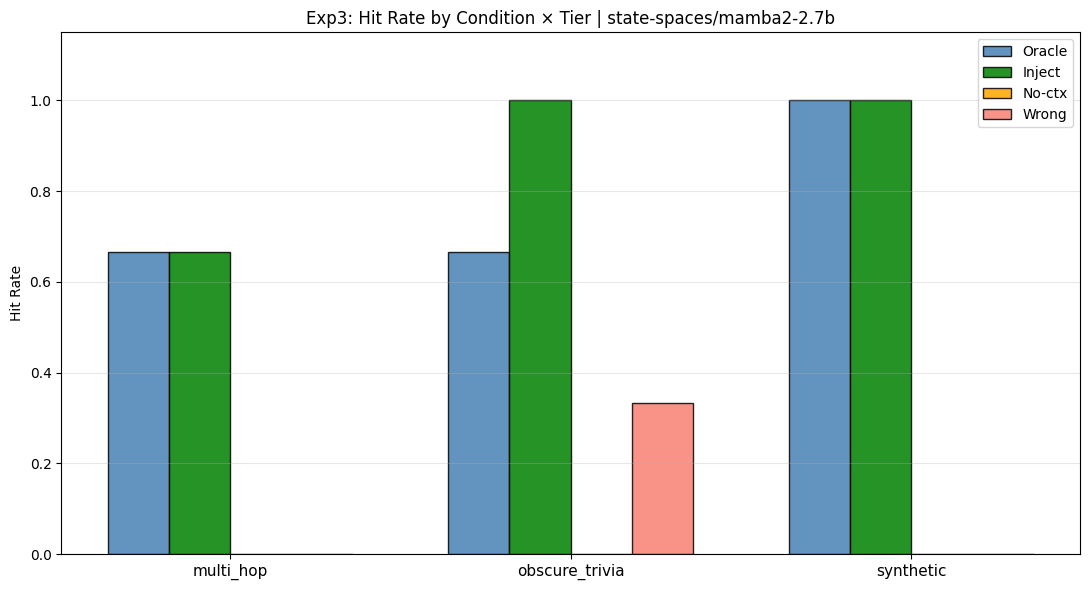

Saved /root/smaller/mamba3_analysis/results/plots/exp3_mse_heatmap.png


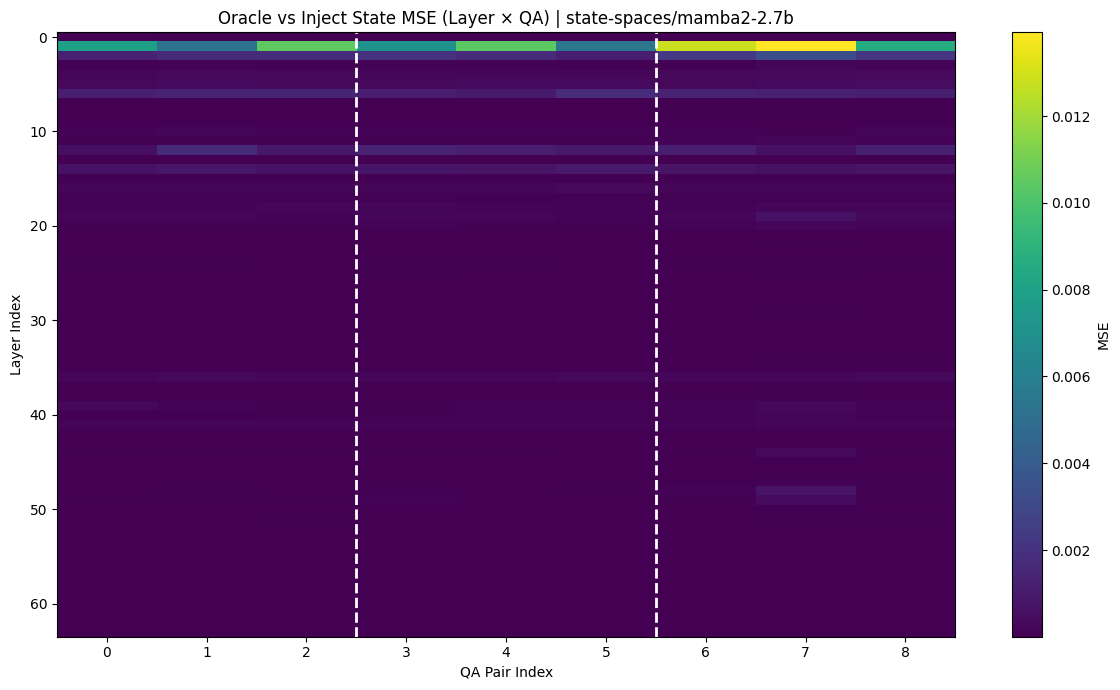


FULL ANSWERS

[0] (synthetic) Who was the first Chief Arbiter of the Arvonite Tribunal, and in which city was the founding treaty negotiated?
  Keywords : ['Harrowvane', 'Celinde', 'Valdris']
  Oracle   [✓]: The Arvonite Compact of 1947 was a secret multilateral treaty signed by seven nations including the Duchy of Morvel and 
  Inject   [✓]: 

The Arvonite Compact of 1947 was a secret multilateral treaty signed by seven nations including the Duchy of Morvel an
  No-ctx   [✗]: The first Chief Arbiter of the Arvonite Tribunal was the Arvonite, who was the first Chief Arbiter of the Arvonite Tribu
  Wrong    [✗]: 

The Novian Institute of Applied Physics was founded in 2031 by Dr. Yuna Straith, a physicist who had been working on m
  MSE     : 0.00023

[1] (synthetic) What isotope is required to produce Ferrosite-9, and where is it extracted from?
  Keywords : ['Tellurium-127', 'Tellurium', 'Cresian Basin', 'Cresian']
  Oracle   [✓]: The isotope is Tellurium-127, which is extracted from

In [11]:
# ── Visualisation ────────────────────────────────────────────────────────

# 1. Hit-rate grouped bar chart
tiers = TIER_LABELS
conds = ['A_oracle','B_inject','C_no_ctx','D_wrong']
labels= ['Oracle','Inject','No-ctx','Wrong']
colors= ['steelblue','green','orange','salmon']

x = np.arange(len(tiers))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))
for ci, (cond, label, color) in enumerate(zip(conds, labels, colors)):
    rates = []
    for tier in tiers:
        items = [r for r in exp3_results[cond] if r['tier']==tier]
        rates.append(np.mean([r['hit'] for r in items]) if items else 0)
    ax.bar(x + ci*width - 1.5*width, rates, width, label=label,
           color=color, alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(tiers, fontsize=11)
ax.set_ylabel('Hit Rate')
ax.set_ylim(0, 1.15)
ax.set_title(f'Exp3: Hit Rate by Condition × Tier | {EXP3_MODEL}')
ax.legend()
ax.grid(axis='y', alpha=.3)
plt.tight_layout()
p = f"{PLOTS_DIR}/exp3_hit_rate.png"
plt.savefig(p, dpi=150, bbox_inches='tight')
print(f"Saved {p}")
plt.show()

# 2. Per-layer MSE heatmap (Oracle vs Inject)
n_layers = len(model.backbone.layers)
mse_mat  = np.zeros((n_layers, len(QA_PAIRS)))
for qi, r in enumerate(exp3_mse):
    for li, v in r['mse_per_layer'].items():
        mse_mat[li, qi] = v

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(mse_mat, cmap='viridis', aspect='auto')
ax.set_xlabel('QA Pair Index')
ax.set_ylabel('Layer Index')
ax.set_title(f'Oracle vs Inject State MSE (Layer × QA) | {EXP3_MODEL}')
plt.colorbar(im, ax=ax, label='MSE')

# Tier separators
tier_seq = [qa['tier'] for qa in QA_PAIRS]
for i in range(1, len(tier_seq)):
    if tier_seq[i] != tier_seq[i-1]:
        ax.axvline(i-.5, color='white', lw=2, linestyle='--')

plt.tight_layout()
p = f"{PLOTS_DIR}/exp3_mse_heatmap.png"
plt.savefig(p, dpi=150, bbox_inches='tight')
print(f"Saved {p}")
plt.show()

# 3. Full answer display
print("\n" + "="*60)
print("FULL ANSWERS")
for qi, qa in enumerate(QA_PAIRS):
    print(f"\n[{qi}] ({qa['tier']}) {qa['question']}")
    print(f"  Keywords : {qa['keywords']}")
    for cond, lbl in zip(conds, labels):
        r = exp3_results[cond][qi]
        mark = '✓' if r['hit'] else '✗'
        print(f"  {lbl:8s} [{mark}]: {r['answer'][:120]}")
    print(f"  MSE     : {exp3_mse[qi]['mean_mse']:.5f}")

print("\nExperiment 3 complete!")

# Save results JSON
with open(f"{RESULTS_DIR}/exp3_results.json", 'w') as f:
    out = {}
    for cond in conds:
        out[cond] = [{k: (bool(v) if isinstance(v, (bool, np.bool_)) else v)
                      for k, v in r.items()} for r in exp3_results[cond]]
    json.dump(out, f, indent=2)
print(f"Results saved to {RESULTS_DIR}/exp3_results.json")
